<a href="https://colab.research.google.com/github/jpccmacedo-cmyk/CEP_Exercicios/blob/main/Exerc%C3%ADcios_Cap%C3%ADtulo_6___CEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercícios CEP - Aluno: João Pedro Cavalcante Castro Macedo - Matrícula: 202029219

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configuração global de estilo - Padrão Acadêmico
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.color': '#cccccc',
    'font.size': 11, 'axes.titlesize': 13, 'lines.linewidth': 1.5,
})

# Tabela de Constantes de Montgomery
CONSTANTES = {
    2: {'A2': 1.880, 'D3': 0, 'D4': 3.267, 'd2': 1.128, 'A3': 2.659, 'B3': 0, 'B4': 3.267, 'c4': 0.7979},
    3: {'A2': 1.023, 'D3': 0, 'D4': 2.574, 'd2': 1.693, 'A3': 1.954, 'B3': 0, 'B4': 2.568, 'c4': 0.8862},
    4: {'A2': 0.729, 'D3': 0, 'D4': 2.282, 'd2': 2.059, 'A3': 1.628, 'B3': 0, 'B4': 2.266, 'c4': 0.9213},
    5: {'A2': 0.577, 'D3': 0, 'D4': 2.114, 'd2': 2.326, 'A3': 1.427, 'B3': 0, 'B4': 2.089, 'c4': 0.9400},
    6: {'A2': 0.483, 'D3': 0, 'D4': 2.004, 'd2': 2.534, 'A3': 1.287, 'B3': 0.030, 'B4': 1.970, 'c4': 0.9515},
    10: {'A2': 0.308, 'D3': 0.223, 'D4': 1.777, 'd2': 3.078, 'A3': 0.975, 'B3': 0.284, 'B4': 1.716, 'c4': 0.9727},
}

def plotar_cartas_brutas(dados_matriz, titulo, tipo='R', especificacao=None):
    df = pd.DataFrame(dados_matriz)
    xbar = df.mean(axis=1).tolist()
    if tipo == 'R':
        var_amostral = (df.max(axis=1) - df.min(axis=1)).tolist()
    else:
        var_amostral = df.std(axis=1, ddof=1).tolist()
    plotar_cartas_resumo(xbar, var_amostral, df.shape[1], titulo, tipo, especificacao)

def plotar_cartas_resumo(xbar, var_amostral, n, titulo, tipo='R', especificacao=None):
    m, xbar_bar, var_media = len(xbar), np.mean(xbar), np.mean(var_amostral)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    if tipo == 'R':
        A2, D3, D4 = CONSTANTES[n]['A2'], CONSTANTES[n]['D3'], CONSTANTES[n]['D4']
        LSC_x, LIC_x = xbar_bar + A2 * var_media, xbar_bar - A2 * var_media
        LSC_var, LIC_var = D4 * var_media, D3 * var_media
        sigma_est = var_media / CONSTANTES[n]['d2']
        titulo_var = 'Carta R (Amplitude)'
    else:
        A3, B3, B4 = CONSTANTES[n]['A3'], CONSTANTES[n]['B3'], CONSTANTES[n]['B4']
        LSC_x, LIC_x = xbar_bar + A3 * var_media, xbar_bar - A3 * var_media
        LSC_var, LIC_var = B4 * var_media, B3 * var_media
        sigma_est = var_media / CONSTANTES[n]['c4']
        titulo_var = 'Carta S (Desvio-Padrão)'

    # Gráfico X-Barra
    ax1.plot(range(1, m+1), xbar, marker='o', color='#1f77b4')
    ax1.axhline(LSC_x, color='red', linestyle='--', label=f'LSC ({LSC_x:.3f})')
    ax1.axhline(xbar_bar, color='green', label=f'LC ({xbar_bar:.3f})')
    ax1.axhline(LIC_x, color='red', linestyle='--', label=f'LIC ({LIC_x:.3f})')
    ax1.set_title(f'Carta $\\bar{{X}}$ - {titulo}')
    ax1.set_xticks(range(1, m+1))
    ax1.legend(loc='upper right')

    # Gráfico R ou S
    ax2.plot(range(1, m+1), var_amostral, marker='o', color='#ff7f0e')
    ax2.axhline(LSC_var, color='red', linestyle='--', label=f'LSC ({LSC_var:.3f})')
    ax2.axhline(var_media, color='green', label=f'LC ({var_media:.3f})')
    ax2.axhline(LIC_var, color='red', linestyle='--', label=f'LIC ({LIC_var:.3f})')
    ax2.set_title(f'{titulo_var} - {titulo}')
    ax2.set_xticks(range(1, m+1))
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    print(f"--- RESUMO ESTATÍSTICO: {titulo} ---")
    print(f"Média do Processo (X̄̄): {xbar_bar:.4f}")
    print(f"Variabilidade Média ({tipo}̄): {var_media:.4f}")
    print(f"Desvio-padrão estimado (σ^): {sigma_est:.4f}")
    if especificacao:
        Cp = (especificacao[1] - especificacao[0]) / (6 * sigma_est)
        print(f"Cp (Capacidade do Processo): {Cp:.4f}")

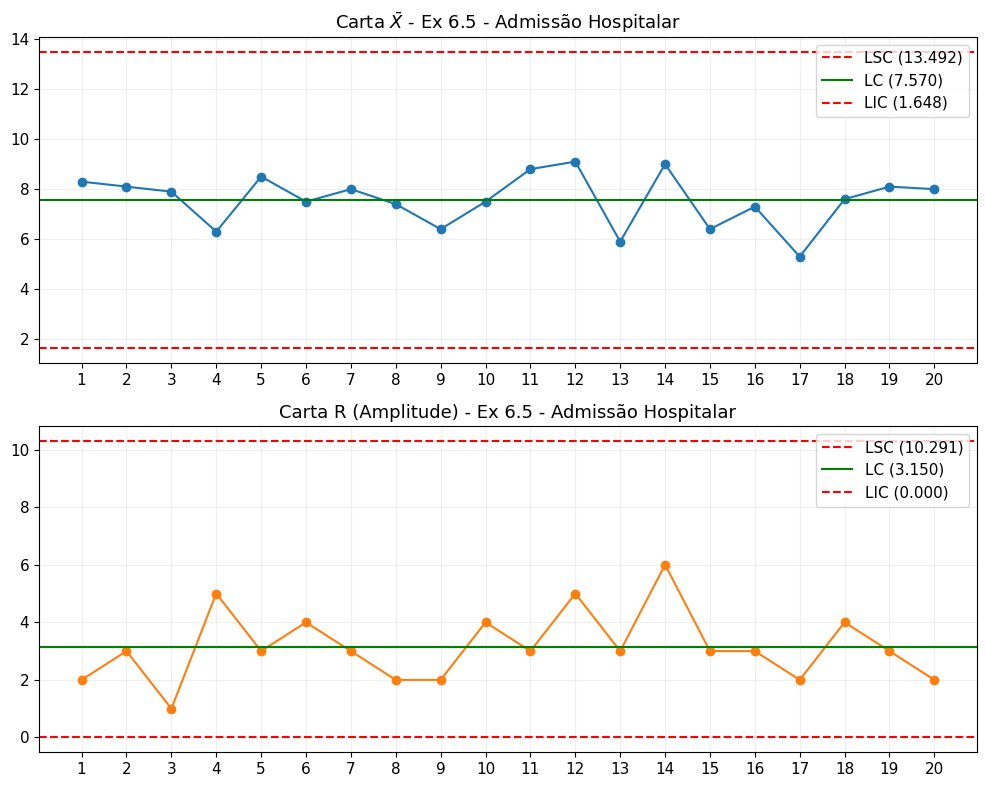

--- RESUMO ESTATÍSTICO: Ex 6.5 - Admissão Hospitalar ---
Média do Processo (X̄̄): 7.5700
Variabilidade Média (R̄): 3.1500
Desvio-padrão estimado (σ^): 2.7926


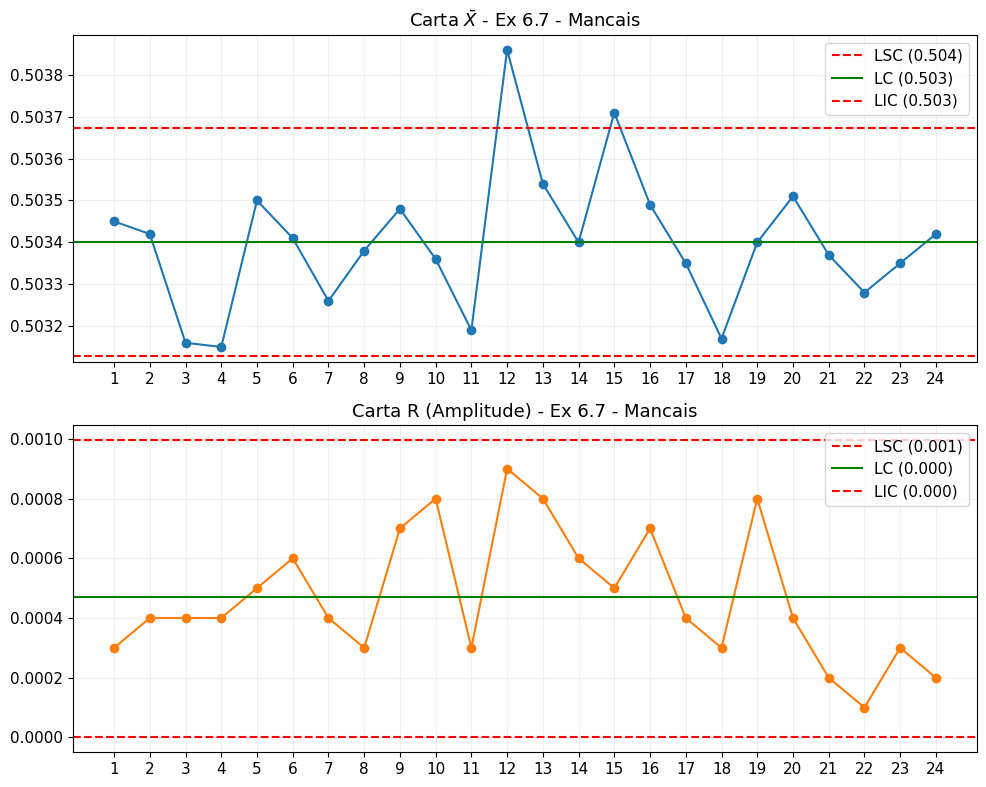

--- RESUMO ESTATÍSTICO: Ex 6.7 - Mancais ---
Média do Processo (X̄̄): 0.5034
Variabilidade Média (R̄): 0.0005
Desvio-padrão estimado (σ^): 0.0002
Cp (Capacidade do Processo): 1.6467


In [6]:
# EXERCÍCIO 6.5 (Tabela 6E.1) - Admissão Hospitalar (n=2)
xbar_6_5 = [8.3, 8.1, 7.9, 6.3, 8.5, 7.5, 8.0, 7.4, 6.4, 7.5, 8.8, 9.1, 5.9, 9.0, 6.4, 7.3, 5.3, 7.6, 8.1, 8.0]
r_6_5 = [2, 3, 1, 5, 3, 4, 3, 2, 2, 4, 3, 5, 3, 6, 3, 3, 2, 4, 3, 2]
plotar_cartas_resumo(xbar=xbar_6_5, var_amostral=r_6_5, n=2, titulo="Ex 6.5 - Admissão Hospitalar")

# EXERCÍCIO 6.7 (Tabela 6E.2) - Mancais (n=5)
# O livro registra os dados em formato resumido (34.5 = 0.50345)
xbar_raw = [34.5, 34.2, 31.6, 31.5, 35.0, 34.1, 32.6, 33.8, 34.8, 33.6, 31.9, 38.6, 35.4, 34.0, 37.1, 34.9, 33.5, 31.7, 34.0, 35.1, 33.7, 32.8, 33.5, 34.2]
r_raw = [3, 4, 4, 4, 5, 6, 4, 3, 7, 8, 3, 9, 8, 6, 5, 7, 4, 3, 8, 4, 2, 1, 3, 2]

# Transformando de volta para a escala polegadas conforme enunciado
xbar_6_7 = [0.5 + (x/10000) for x in xbar_raw]
r_6_7 = [(r/10000) for r in r_raw]

# Especificação: 0.5030 ± 0.0010
plotar_cartas_resumo(xbar=xbar_6_7, var_amostral=r_6_7, n=5, titulo="Ex 6.7 - Mancais", especificacao=(0.5020, 0.5040))

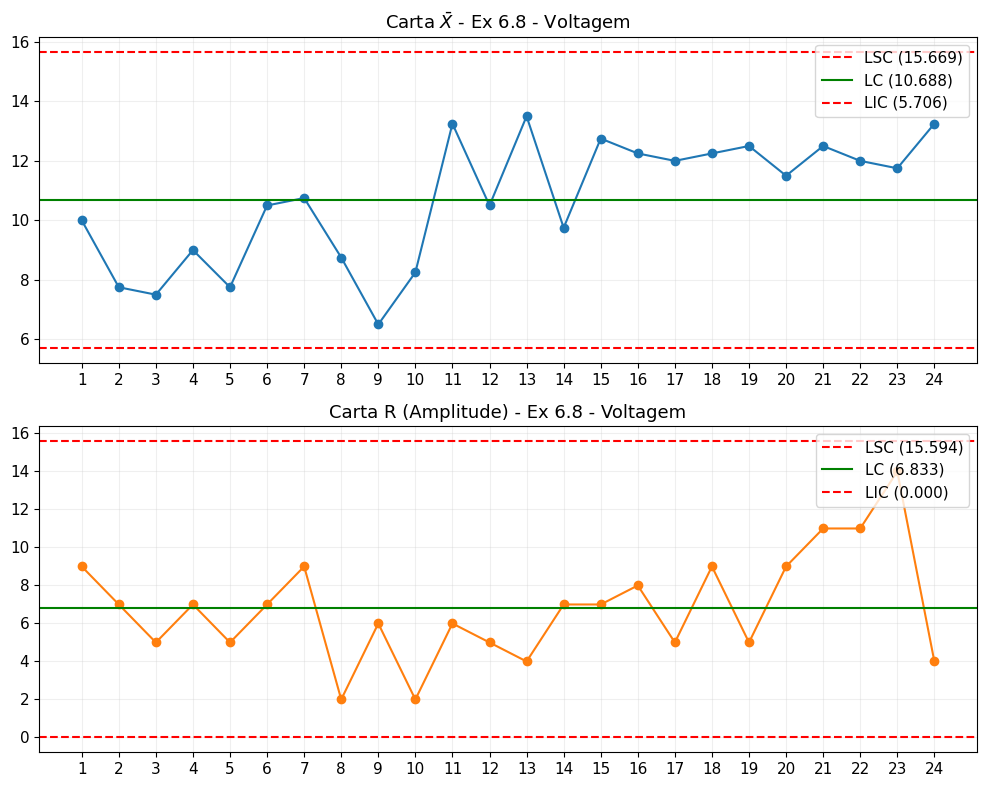

--- RESUMO ESTATÍSTICO: Ex 6.8 - Voltagem ---
Média do Processo (X̄̄): 10.6875
Variabilidade Média (R̄): 6.8333
Desvio-padrão estimado (σ^): 3.3188
Cp (Capacidade do Processo): 5.0220


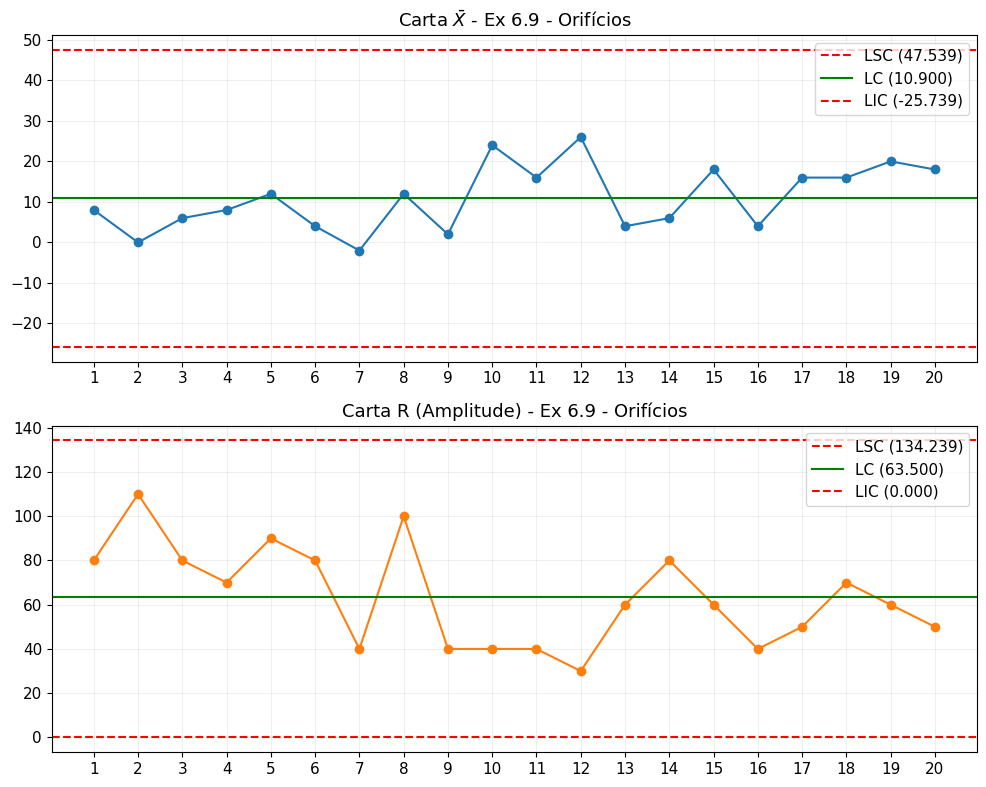

--- RESUMO ESTATÍSTICO: Ex 6.9 - Orifícios ---
Média do Processo (X̄̄): 10.9000
Variabilidade Média (R̄): 63.5000
Desvio-padrão estimado (σ^): 27.3001
Cp (Capacidade do Processo): 1.2210


In [7]:
# EXERCÍCIO 6.8 (Tabela 6E.3) - Voltagem de Saída (n=4)
# xi = (voltagem - 350)*10. Especificação original: 350 ± 5 V (Convertida = ± 50)
dados_6_8 = [
    [6, 9, 10, 15], [10, 4, 6, 11], [7, 8, 10, 5], [8, 9, 6, 13],
    [5, 9, 10, 7], [13, 6, 12, 11], [10, 10, 7, 16], [10, 8, 9, 8],
    [7, 5, 10, 4], [9, 9, 7, 8], [12, 10, 15, 16], [10, 13, 11, 8],
    [12, 14, 16, 12], [6, 13, 9, 11], [13, 16, 9, 13], [15, 14, 7, 13],
    [10, 12, 15, 11], [7, 10, 16, 16], [15, 10, 11, 14], [17, 9, 8, 12],
    [10, 18, 15, 7], [10, 11, 19, 8], [6, 9, 12, 20], [13, 14, 11, 15]
]
plotar_cartas_brutas(dados_6_8, "Ex 6.8 - Voltagem", especificacao=(-50, 50))


# EXERCÍCIO 6.9 (Tabela 6E.4) - Orifícios em Fibra de Carbono (n=5)
# Especificação: Nominal ± 100
dados_6_9 = [
    [-30, 50, -20, 10, 30], [0, 50, -60, -20, 30], [-50, 10, 20, 30, 20],
    [-10, -10, 30, -20, 50], [20, -40, 50, 20, 10], [0, 0, 40, -40, 20],
    [0, 0, 20, -20, -10], [70, -30, 30, -10, 0], [0, 0, 20, -20, 10],
    [10, 20, 30, 10, 50], [40, 0, 20, 0, 20], [30, 20, 30, 10, 40],
    [30, -30, 0, 10, 10], [30, -10, 50, -10, -30], [10, -10, 50, 40, 0],
    [0, 0, 30, -10, 0], [20, 20, 30, 30, -20], [10, -20, 50, 30, 10],
    [50, -10, 40, 20, 0], [50, 0, 0, 30, 10]
]
plotar_cartas_brutas(dados_6_9, "Ex 6.9 - Orifícios", especificacao=(-100, 100))

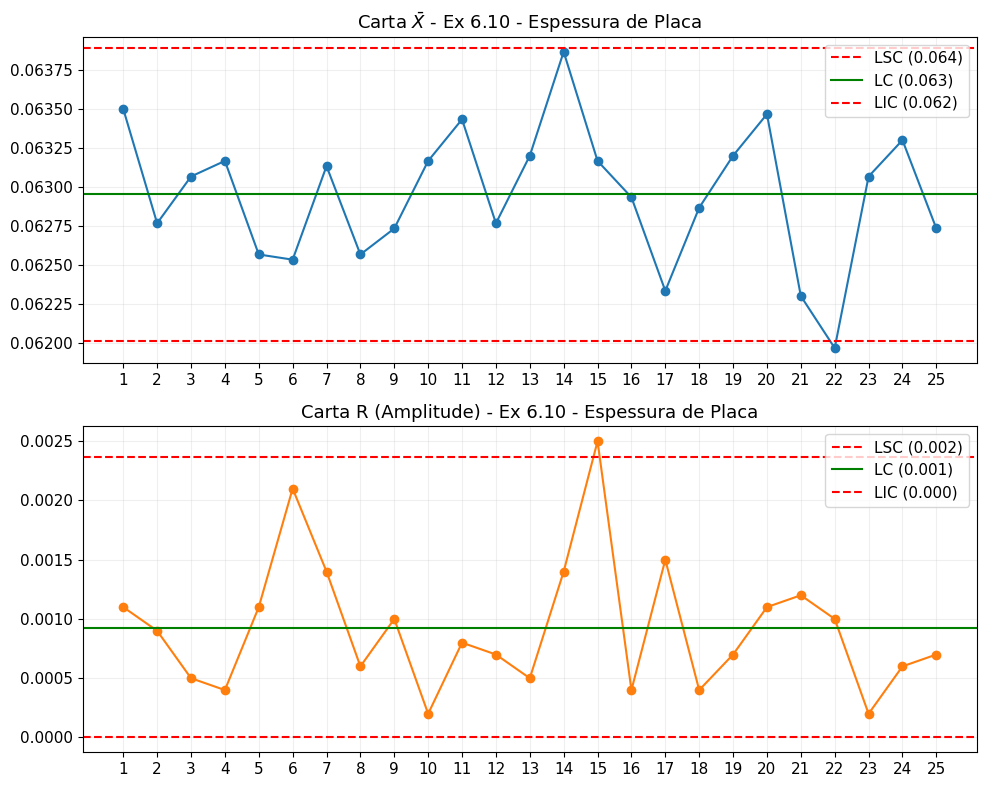

--- RESUMO ESTATÍSTICO: Ex 6.10 - Espessura de Placa ---
Média do Processo (X̄̄): 0.0630
Variabilidade Média (R̄): 0.0009
Desvio-padrão estimado (σ^): 0.0005
Cp (Capacidade do Processo): 0.9201


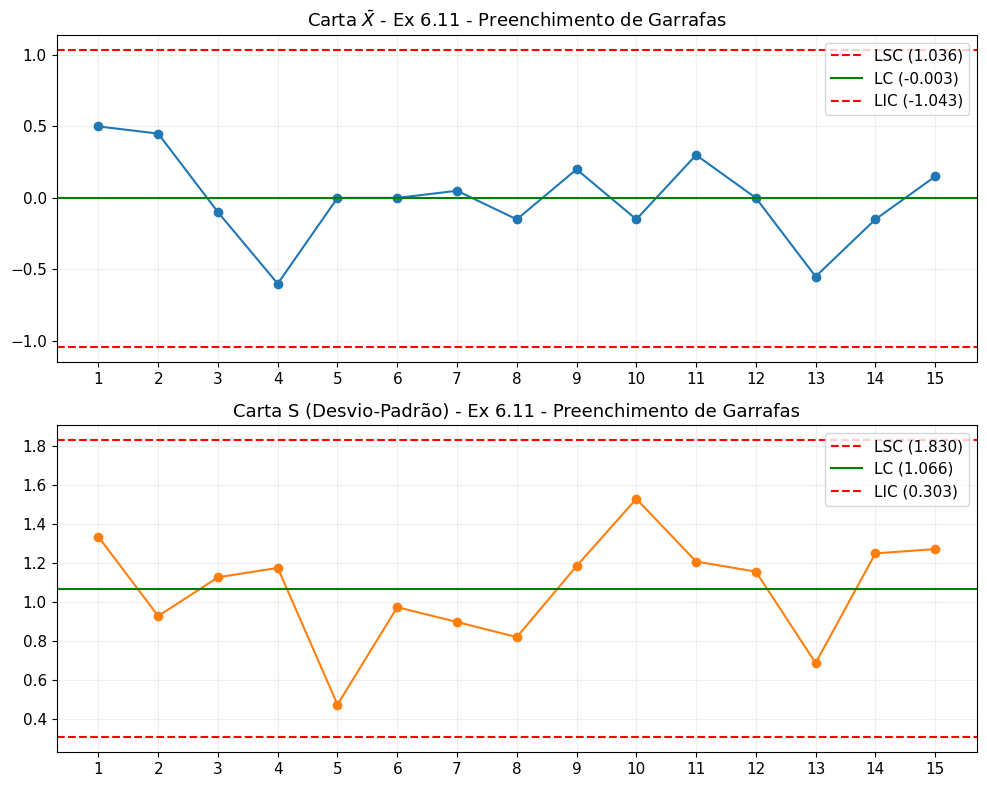

--- RESUMO ESTATÍSTICO: Ex 6.11 - Preenchimento de Garrafas ---
Média do Processo (X̄̄): -0.0033
Variabilidade Média (S̄): 1.0662
Desvio-padrão estimado (σ^): 1.0961


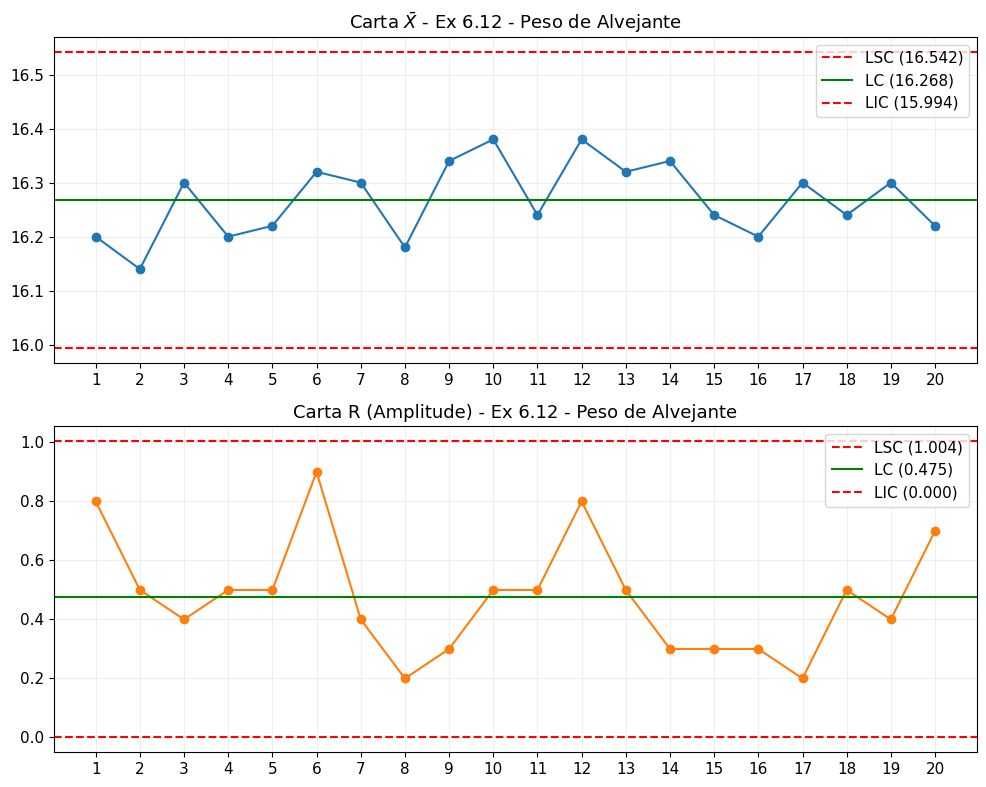

--- RESUMO ESTATÍSTICO: Ex 6.12 - Peso de Alvejante ---
Média do Processo (X̄̄): 16.2680
Variabilidade Média (R̄): 0.4750
Desvio-padrão estimado (σ^): 0.2042
Cp (Capacidade do Processo): 0.8161


In [8]:
# EXERCÍCIO 6.10 (Tabela 6E.5) - Placa de Circuito Impresso (n=3)
dados_6_10 = [
    [0.0629, 0.0636, 0.0640], [0.0630, 0.0631, 0.0622], [0.0628, 0.0631, 0.0633], [0.0634, 0.0630, 0.0631], [0.0619, 0.0628, 0.0630],
    [0.0613, 0.0629, 0.0634], [0.0630, 0.0639, 0.0625], [0.0628, 0.0627, 0.0622], [0.0623, 0.0626, 0.0633], [0.0631, 0.0631, 0.0633],
    [0.0635, 0.0630, 0.0638], [0.0623, 0.0630, 0.0630], [0.0635, 0.0631, 0.0630], [0.0645, 0.0640, 0.0631], [0.0619, 0.0644, 0.0632],
    [0.0631, 0.0627, 0.0630], [0.0616, 0.0623, 0.0631], [0.0630, 0.0630, 0.0626], [0.0636, 0.0631, 0.0629], [0.0640, 0.0635, 0.0629],
    [0.0628, 0.0625, 0.0616], [0.0615, 0.0625, 0.0619], [0.0630, 0.0632, 0.0630], [0.0635, 0.0629, 0.0635], [0.0623, 0.0629, 0.0630]
]
plotar_cartas_brutas(dados_6_10, "Ex 6.10 - Espessura de Placa", tipo='R', especificacao=(0.0615, 0.0645))


# EXERCÍCIO 6.11 (Tabela 6E.6) - Volume de Garrafas (n=10) -> UTILIZA CARTA S
dados_6_11 = [
    [2.5, 0.5, 2.0, -1.0, 1.0, -1.0, 0.5, 1.5, 0.5, -1.5],
    [0.0, 0.0, 0.5, 1.0, 1.5, 1.0, -1.0, 1.0, 1.5, -1.0],
    [1.5, 1.0, 1.0, -1.0, 0.0, -1.5, -1.0, -1.0, 1.0, -1.0],
    [0.0, 0.5, -2.0, 0.0, -1.0, 1.5, -1.5, 0.0, -2.0, -1.5],
    [0.0, 0.0, 0.0, -0.5, 0.5, 1.0, -0.5, -0.5, 0.0, 0.0],
    [1.0, -0.5, 0.0, 0.0, 0.0, 0.5, -1.0, 1.0, -2.0, 1.0],
    [1.0, -1.0, -1.0, -1.0, 0.0, 1.5, 0.0, 1.0, 0.0, 0.0],
    [0.0, -1.5, -0.5, 1.5, 0.0, 0.0, 0.0, -1.0, 0.5, -0.5],
    [-2.0, -1.5, 1.5, 1.5, 0.0, 0.0, 0.5, 1.0, 0.0, 1.0],
    [-0.5, 3.5, 0.0, -1.0, -1.5, -1.5, -1.0, -1.0, 1.0, 0.5],
    [0.0, 1.5, 0.0, 0.0, 2.0, -1.5, 0.5, -0.5, 2.0, -1.0],
    [0.0, -2.0, -0.5, 0.0, -0.5, 2.0, 1.5, 0.0, 0.5, -1.0],
    [-1.0, -0.5, -0.5, -1.0, 0.0, 0.5, 0.5, -1.5, -1.0, -1.0],
    [0.5, 1.0, -1.0, -0.5, -2.0, -1.0, -1.5, 0.0, 1.5, 1.5],
    [1.0, 0.0, 1.5, 1.5, 1.0, -1.0, 0.0, 1.0, -2.0, -1.5]
]
plotar_cartas_brutas(dados_6_11, "Ex 6.11 - Preenchimento de Garrafas", tipo='S')


# EXERCÍCIO 6.12 (Tabela 6E.7) - Peso Líquido de Alvejante (n=5)
dados_6_12 = [
    [15.8, 16.3, 16.2, 16.1, 16.6], [16.3, 15.9, 15.9, 16.2, 16.4],
    [16.1, 16.2, 16.5, 16.4, 16.3], [16.3, 16.2, 15.9, 16.4, 16.2],
    [16.1, 16.1, 16.4, 16.5, 16.0], [16.1, 15.8, 16.7, 16.6, 16.4],
    [16.1, 16.3, 16.5, 16.1, 16.5], [16.2, 16.1, 16.2, 16.1, 16.3],
    [16.3, 16.2, 16.4, 16.3, 16.5], [16.6, 16.3, 16.4, 16.1, 16.5],
    [16.2, 16.4, 15.9, 16.3, 16.4], [15.9, 16.6, 16.7, 16.2, 16.5],
    [16.4, 16.1, 16.6, 16.4, 16.1], [16.5, 16.3, 16.2, 16.3, 16.4],
    [16.4, 16.1, 16.3, 16.2, 16.2], [16.0, 16.2, 16.3, 16.3, 16.2],
    [16.4, 16.2, 16.4, 16.3, 16.2], [16.0, 16.2, 16.4, 16.5, 16.1],
    [16.4, 16.0, 16.3, 16.4, 16.4], [16.4, 16.4, 16.5, 16.0, 15.8]
]
plotar_cartas_brutas(dados_6_12, "Ex 6.12 - Peso de Alvejante", tipo='R', especificacao=(15.7, 16.7))

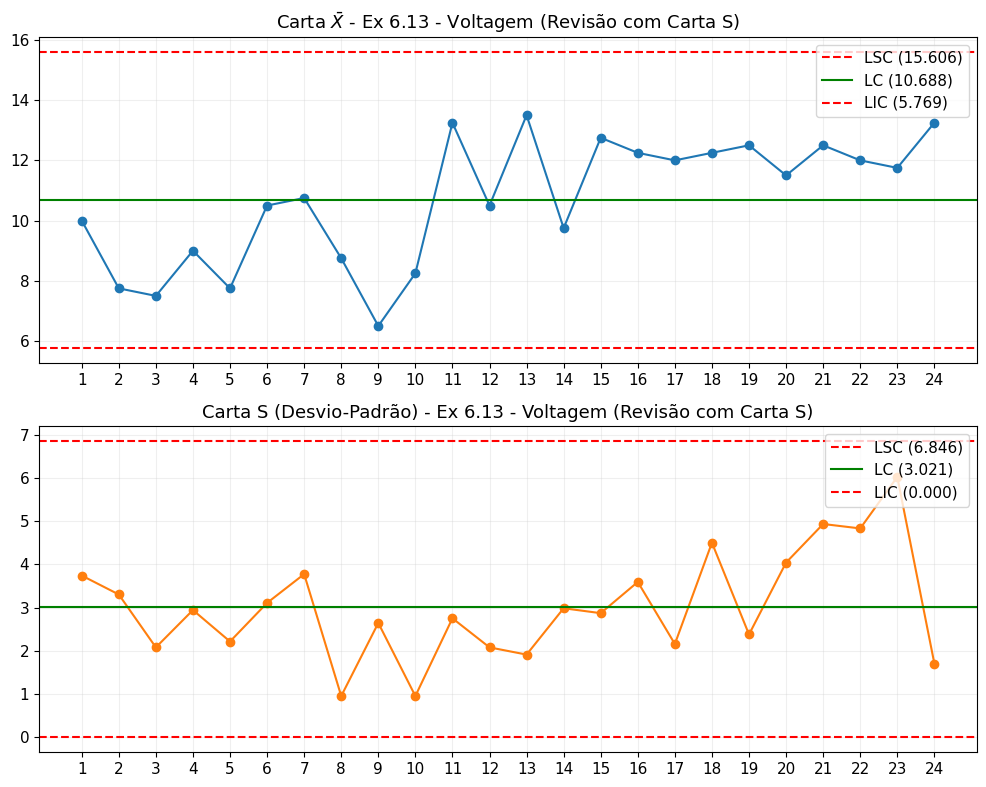

--- RESUMO ESTATÍSTICO: Ex 6.13 - Voltagem (Revisão com Carta S) ---
Média do Processo (X̄̄): 10.6875
Variabilidade Média (S̄): 3.0213
Desvio-padrão estimado (σ^): 3.2793


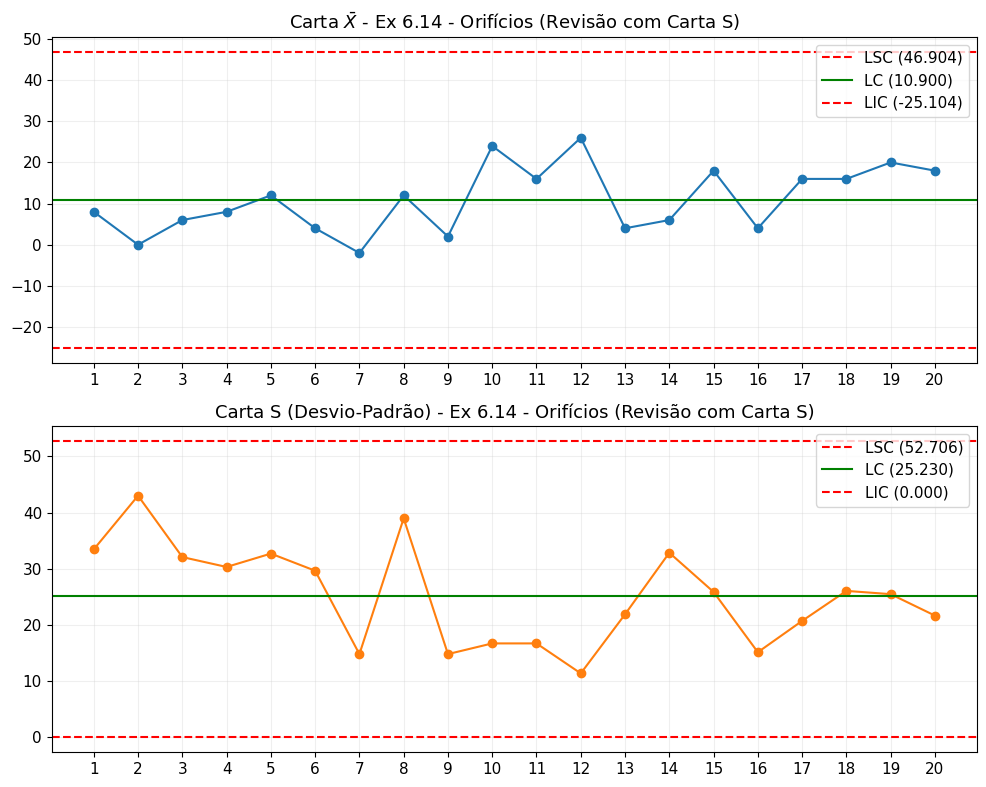

--- RESUMO ESTATÍSTICO: Ex 6.14 - Orifícios (Revisão com Carta S) ---
Média do Processo (X̄̄): 10.9000
Variabilidade Média (S̄): 25.2305
Desvio-padrão estimado (σ^): 26.8409


In [9]:
# EXERCÍCIO 6.13: Refazer o 6.8 (Voltagem) usando Carta S
dados_6_8 = [
    [6, 9, 10, 15], [10, 4, 6, 11], [7, 8, 10, 5], [8, 9, 6, 13],
    [5, 9, 10, 7], [13, 6, 12, 11], [10, 10, 7, 16], [10, 8, 9, 8],
    [7, 5, 10, 4], [9, 9, 7, 8], [12, 10, 15, 16], [10, 13, 11, 8],
    [12, 14, 16, 12], [6, 13, 9, 11], [13, 16, 9, 13], [15, 14, 7, 13],
    [10, 12, 15, 11], [7, 10, 16, 16], [15, 10, 11, 14], [17, 9, 8, 12],
    [10, 18, 15, 7], [10, 11, 19, 8], [6, 9, 12, 20], [13, 14, 11, 15]
]
plotar_cartas_brutas(dados_6_8, "Ex 6.13 - Voltagem (Revisão com Carta S)", tipo='S')


# EXERCÍCIO 6.14: Refazer o 6.9 (Orifícios em Fibra) usando Carta S
dados_6_9 = [
    [-30, 50, -20, 10, 30], [0, 50, -60, -20, 30], [-50, 10, 20, 30, 20],
    [-10, -10, 30, -20, 50], [20, -40, 50, 20, 10], [0, 0, 40, -40, 20],
    [0, 0, 20, -20, -10], [70, -30, 30, -10, 0], [0, 0, 20, -20, 10],
    [10, 20, 30, 10, 50], [40, 0, 20, 0, 20], [30, 20, 30, 10, 40],
    [30, -30, 0, 10, 10], [30, -10, 50, -10, -30], [10, -10, 50, 40, 0],
    [0, 0, 30, -10, 0], [20, 20, 30, 30, -20], [10, -20, 50, 30, 10],
    [50, -10, 40, 20, 0], [50, 0, 0, 30, 10]
]
plotar_cartas_brutas(dados_6_9, "Ex 6.14 - Orifícios (Revisão com Carta S)", tipo='S')

In [10]:
def calcular_limites_diretos(xbar_bar, var_media, n, tipo='R'):
    """Calcula os limites de controle quando o livro já fornece as médias globais"""
    print(f"--- CÁLCULO DIRETO DE LIMITES (n={n}) ---")
    if tipo == 'R':
        A2, D3, D4 = CONSTANTES[n]['A2'], CONSTANTES[n]['D3'], CONSTANTES[n]['D4']
        LSC_x, LIC_x = xbar_bar + A2 * var_media, xbar_bar - A2 * var_media
        LSC_var, LIC_var = D4 * var_media, D3 * var_media
        sigma = var_media / CONSTANTES[n]['d2']
        nome_var = 'R'
    else:
        A3, B3, B4 = CONSTANTES[n]['A3'], CONSTANTES[n]['B3'], CONSTANTES[n]['B4']
        LSC_x, LIC_x = xbar_bar + A3 * var_media, xbar_bar - A3 * var_media
        LSC_var, LIC_var = B4 * var_media, B3 * var_media
        sigma = var_media / CONSTANTES[n]['c4']
        nome_var = 'S'

    print(f"Limites Carta X-barra: LSC = {LSC_x:.4f} | LC = {xbar_bar:.4f} | LIC = {LIC_x:.4f}")
    print(f"Limites Carta {nome_var}: LSC = {LSC_var:.4f} | LC = {var_media:.4f} | LIC = {LIC_var:.4f}")
    print(f"Desvio-padrão estimado (σ^): {sigma:.4f}\n")

# EXERCÍCIO 6.17 (n=6, X̄̄ = 40, R̄ = 5.0)
print("Resultados do Exercício 6.17:")
calcular_limites_diretos(xbar_bar=40.0, var_media=5.0, n=6, tipo='R')

# EXERCÍCIO 6.18 (n=4, X̄̄ = 20.0, S̄ = 1.5)
print("Resultados do Exercício 6.18:")
calcular_limites_diretos(xbar_bar=20.0, var_media=1.5, n=4, tipo='S')

Resultados do Exercício 6.17:
--- CÁLCULO DIRETO DE LIMITES (n=6) ---
Limites Carta X-barra: LSC = 42.4150 | LC = 40.0000 | LIC = 37.5850
Limites Carta R: LSC = 10.0200 | LC = 5.0000 | LIC = 0.0000
Desvio-padrão estimado (σ^): 1.9732

Resultados do Exercício 6.18:
--- CÁLCULO DIRETO DE LIMITES (n=4) ---
Limites Carta X-barra: LSC = 22.4420 | LC = 20.0000 | LIC = 17.5580
Limites Carta S: LSC = 3.3990 | LC = 1.5000 | LIC = 0.0000
Desvio-padrão estimado (σ^): 1.6281



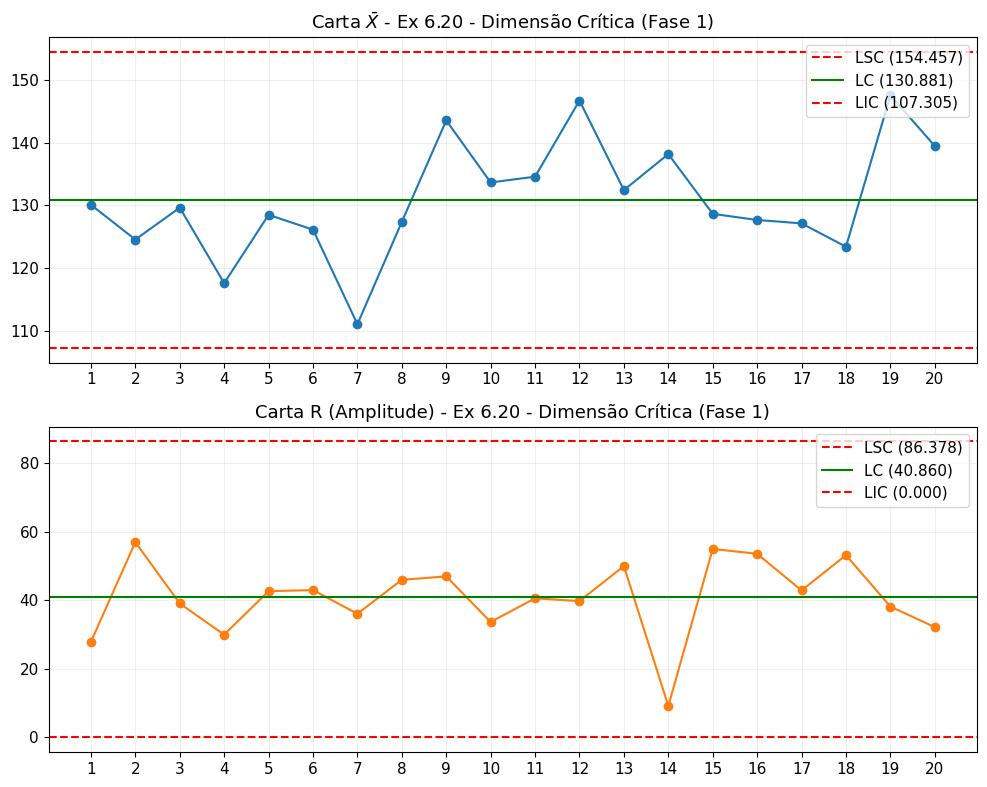

--- RESUMO ESTATÍSTICO: Ex 6.20 - Dimensão Crítica (Fase 1) ---
Média do Processo (X̄̄): 130.8810
Variabilidade Média (R̄): 40.8600
Desvio-padrão estimado (σ^): 17.5666


In [11]:
# EXERCÍCIO 6.20 (Tabela 6E.9) - Dimensão crítica de usinagem (n=5)
dados_6_20 = [
    [138.1, 110.8, 138.7, 137.4, 125.4],
    [149.3, 142.1, 105.0, 134.0, 92.3],
    [115.9, 135.6, 124.2, 155.0, 117.4],
    [118.5, 116.5, 130.2, 122.6, 100.2],
    [108.2, 123.8, 117.1, 142.4, 150.9],
    [102.8, 112.0, 135.0, 135.0, 145.8],
    [120.4, 84.3, 112.8, 118.5, 119.3],
    [132.7, 151.1, 124.0, 123.9, 105.1],
    [136.4, 126.2, 154.7, 127.1, 173.2],
    [135.0, 115.4, 149.1, 138.3, 130.4],
    [139.6, 127.9, 151.1, 143.7, 110.5],
    [125.3, 160.2, 130.4, 152.4, 165.1],
    [145.7, 101.8, 149.5, 113.3, 151.8],
    [138.6, 139.0, 131.9, 140.2, 141.1],
    [110.1, 114.6, 165.1, 113.8, 139.6],
    [145.2, 101.0, 154.6, 120.2, 117.3],
    [125.9, 135.3, 121.5, 147.9, 105.0],
    [129.7, 97.3, 130.5, 109.0, 150.5],
    [123.4, 150.0, 161.6, 148.4, 154.2],
    [144.8, 138.3, 119.6, 151.8, 142.7]
]
plotar_cartas_brutas(dados_6_20, "Ex 6.20 - Dimensão Crítica (Fase 1)", tipo='R')

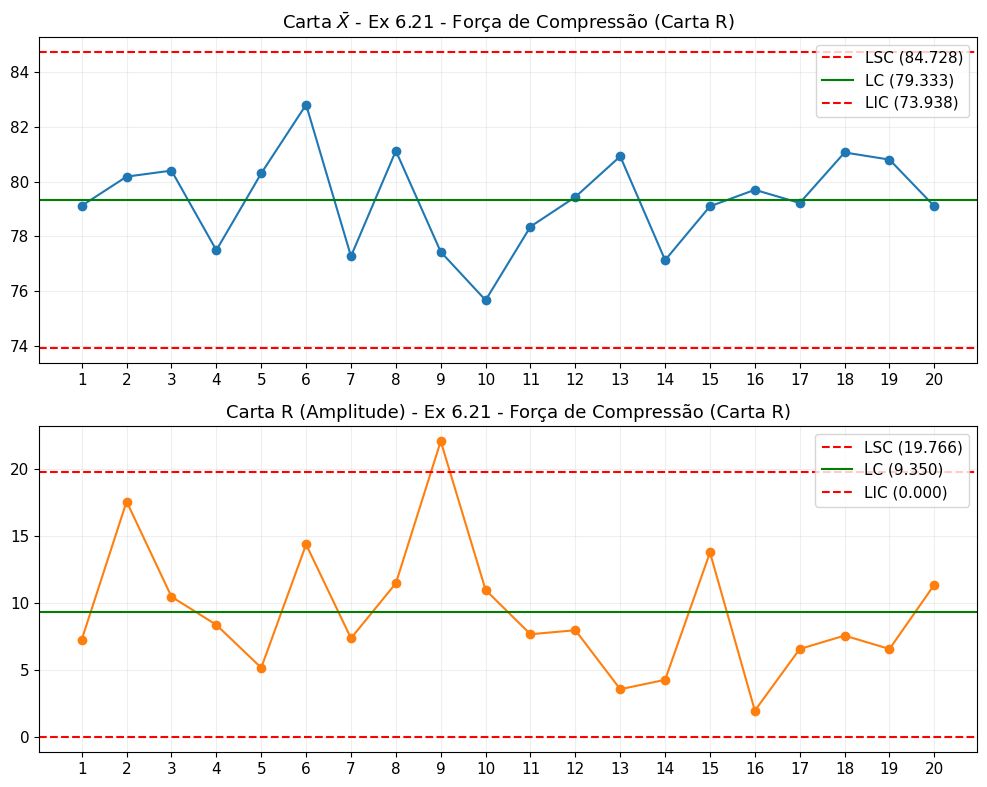

--- RESUMO ESTATÍSTICO: Ex 6.21 - Força de Compressão (Carta R) ---
Média do Processo (X̄̄): 79.3330
Variabilidade Média (R̄): 9.3500
Desvio-padrão estimado (σ^): 4.0198


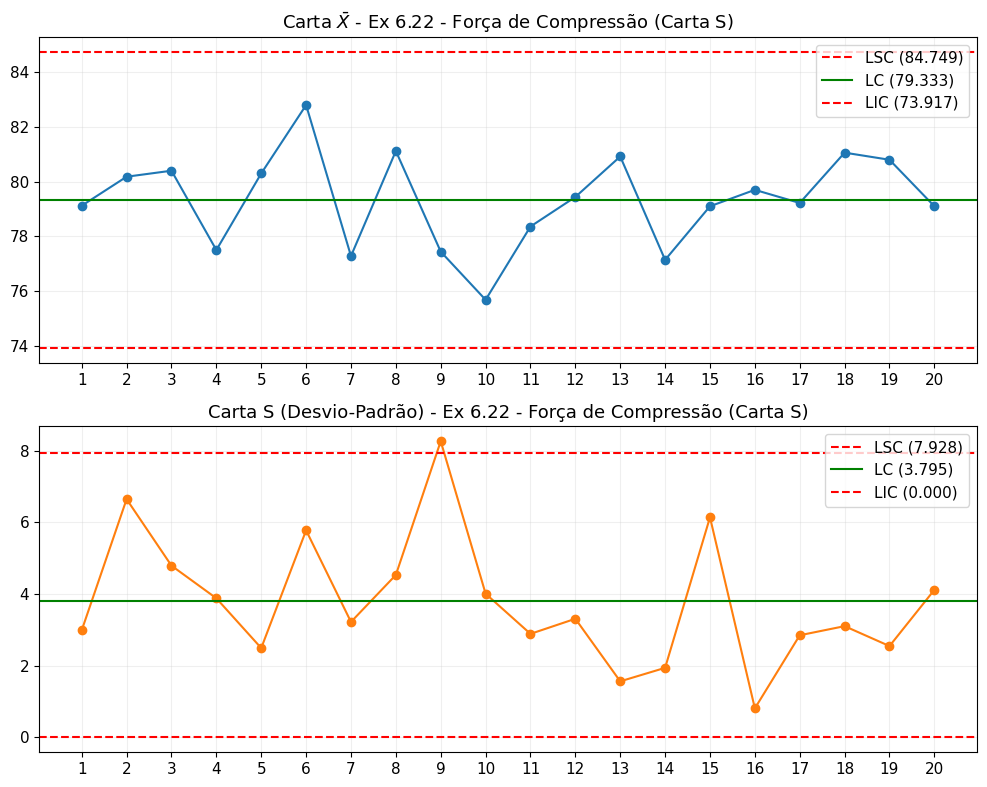

--- RESUMO ESTATÍSTICO: Ex 6.22 - Força de Compressão (Carta S) ---
Média do Processo (X̄̄): 79.3330
Variabilidade Média (S̄): 3.7951
Desvio-padrão estimado (σ^): 4.0374


In [12]:
# EXERCÍCIO 6.21 (Tabela 6E.12) - Força de Compressão em Injeção Plástica (n=5)
dados_6_21 = [
    [83.0, 81.2, 78.7, 75.7, 77.0],
    [88.6, 78.3, 78.8, 71.0, 84.2],
    [85.7, 75.8, 84.3, 75.2, 81.0],
    [80.8, 74.4, 82.5, 74.1, 75.7],
    [83.4, 78.4, 82.6, 78.2, 78.9],
    [75.3, 79.9, 87.3, 89.7, 81.8],
    [74.5, 78.0, 80.8, 73.4, 79.7],
    [79.2, 84.4, 81.5, 86.0, 74.5],
    [80.5, 86.2, 76.2, 64.1, 80.2],
    [75.7, 75.2, 71.1, 82.1, 74.3],
    [80.0, 81.5, 78.4, 73.8, 78.1],
    [80.6, 81.8, 79.3, 73.8, 81.7],
    [82.7, 81.3, 79.1, 82.0, 79.5],
    [79.2, 74.9, 78.6, 77.7, 75.3],
    [85.5, 82.1, 82.8, 73.4, 71.7],
    [78.8, 79.6, 80.2, 79.1, 80.8],
    [82.1, 78.2, 75.5, 78.2, 82.1],
    [84.5, 76.9, 83.5, 81.2, 79.2],
    [79.0, 77.8, 81.2, 84.4, 81.6],
    [84.5, 73.1, 78.6, 78.7, 80.6]
]

# 6.21: Análise com Carta de Amplitude (R)
plotar_cartas_brutas(dados_6_21, "Ex 6.21 - Força de Compressão (Carta R)", tipo='R')

# 6.22: Análise com Carta de Desvio-Padrão (S)
plotar_cartas_brutas(dados_6_21, "Ex 6.22 - Força de Compressão (Carta S)", tipo='S')

In [13]:
# Atualizando o dicionário de constantes para suportar n=7, n=8 e n=9
CONSTANTES.update({
    7: {'A2': 0.419, 'D3': 0.076, 'D4': 1.924, 'd2': 2.704, 'A3': 1.182, 'B3': 0.118, 'B4': 1.882, 'c4': 0.9594},
    8: {'A2': 0.373, 'D3': 0.136, 'D4': 1.864, 'd2': 2.847, 'A3': 1.099, 'B3': 0.185, 'B4': 1.815, 'c4': 0.9650},
    9: {'A2': 0.337, 'D3': 0.184, 'D4': 1.816, 'd2': 2.970, 'A3': 1.032, 'B3': 0.239, 'B4': 1.761, 'c4': 0.9693}
})

def limites_pelos_somatorios(soma_xbar, soma_var, m, n, tipo='R'):
    """Calcula os limites dividindo os somatórios fornecidos no livro pelo número de amostras (m)"""
    xbar_bar = soma_xbar / m
    var_media = soma_var / m

    print(f"Média Global (LC X-barra): {xbar_bar:.4f}")
    print(f"Variabilidade (LC {tipo}): {var_media:.4f}")

    if tipo == 'R':
        A2, D3, D4 = CONSTANTES[n]['A2'], CONSTANTES[n]['D3'], CONSTANTES[n]['D4']
        print(f"Limites Carta X-barra: [{xbar_bar - A2*var_media:.4f} , {xbar_bar + A2*var_media:.4f}]")
        print(f"Limites Carta R:       [{D3*var_media:.4f} , {D4*var_media:.4f}]")
        print(f"Desvio-padrão (σ^):    {var_media / CONSTANTES[n]['d2']:.4f}\n")
    else:
        A3, B3, B4 = CONSTANTES[n]['A3'], CONSTANTES[n]['B3'], CONSTANTES[n]['B4']
        print(f"Limites Carta X-barra: [{xbar_bar - A3*var_media:.4f} , {xbar_bar + A3*var_media:.4f}]")
        print(f"Limites Carta S:       [{B3*var_media:.4f} , {B4*var_media:.4f}]")
        print(f"Desvio-padrão (σ^):    {var_media / CONSTANTES[n]['c4']:.4f}\n")

print("=== EXERCÍCIO 6.27 (n=7, m=35) ===")
limites_pelos_somatorios(soma_xbar=7805, soma_var=1200, m=35, n=7, tipo='R')

print("=== EXERCÍCIO 6.28 (n=5, m=25) ===")
limites_pelos_somatorios(soma_xbar=662.50, soma_var=9.00, m=25, n=5, tipo='R')

print("=== EXERCÍCIO 6.30 (n=3, m=20) ===")
limites_pelos_somatorios(soma_xbar=5550, soma_var=150, m=20, n=3, tipo='R')

print("=== EXERCÍCIO 6.31 (n=3, m=25, Carta S) ===")
limites_pelos_somatorios(soma_xbar=56.25, soma_var=44.20, m=25, n=3, tipo='S')

=== EXERCÍCIO 6.27 (n=7, m=35) ===
Média Global (LC X-barra): 223.0000
Variabilidade (LC R): 34.2857
Limites Carta X-barra: [208.6343 , 237.3657]
Limites Carta R:       [2.6057 , 65.9657]
Desvio-padrão (σ^):    12.6796

=== EXERCÍCIO 6.28 (n=5, m=25) ===
Média Global (LC X-barra): 26.5000
Variabilidade (LC R): 0.3600
Limites Carta X-barra: [26.2923 , 26.7077]
Limites Carta R:       [0.0000 , 0.7610]
Desvio-padrão (σ^):    0.1548

=== EXERCÍCIO 6.30 (n=3, m=20) ===
Média Global (LC X-barra): 277.5000
Variabilidade (LC R): 7.5000
Limites Carta X-barra: [269.8275 , 285.1725]
Limites Carta R:       [0.0000 , 19.3050]
Desvio-padrão (σ^):    4.4300

=== EXERCÍCIO 6.31 (n=3, m=25, Carta S) ===
Média Global (LC X-barra): 2.2500
Variabilidade (LC S): 1.7680
Limites Carta X-barra: [-1.2047 , 5.7047]
Limites Carta S:       [0.0000 , 4.5402]
Desvio-padrão (σ^):    1.9950



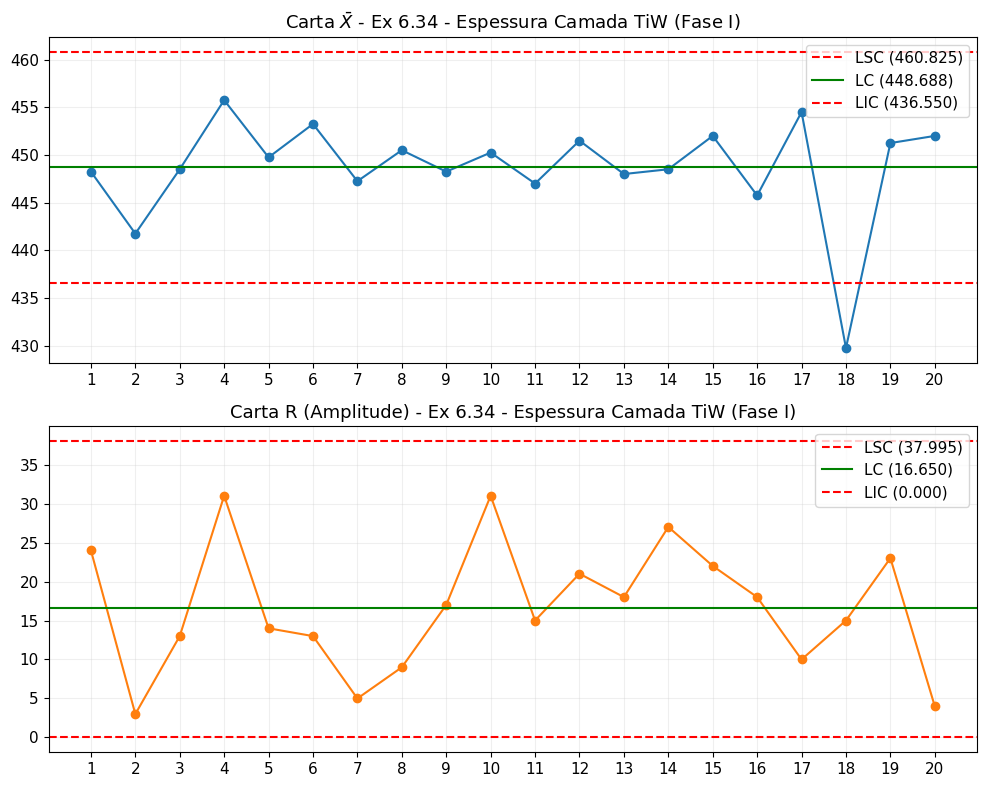

--- RESUMO ESTATÍSTICO: Ex 6.34 - Espessura Camada TiW (Fase I) ---
Média do Processo (X̄̄): 448.6875
Variabilidade Média (R̄): 16.6500
Desvio-padrão estimado (σ^): 8.0864
Cp (Capacidade do Processo): 1.2366


In [14]:
# EXERCÍCIO 6.34 (Tabela 6E.14) - Espessura de Camada de TiW (n=4)
dados_6_34 = [
    [459, 449, 435, 450], [443, 440, 442, 442], [457, 444, 449, 444],
    [469, 463, 453, 438], [443, 457, 445, 454], [444, 456, 456, 457],
    [445, 449, 450, 445], [446, 455, 449, 452], [444, 452, 457, 440],
    [432, 463, 463, 443], [445, 452, 453, 438], [456, 457, 436, 457],
    [459, 445, 441, 447], [441, 465, 438, 450], [460, 453, 457, 438],
    [453, 444, 451, 435], [451, 460, 450, 457], [422, 431, 437, 429],
    [444, 446, 448, 467], [450, 450, 454, 454]
]

# A especificação exigida na parte (d) é 450 ± 30
plotar_cartas_brutas(dados_6_34, "Ex 6.34 - Espessura Camada TiW (Fase I)", tipo='R', especificacao=(420, 480))

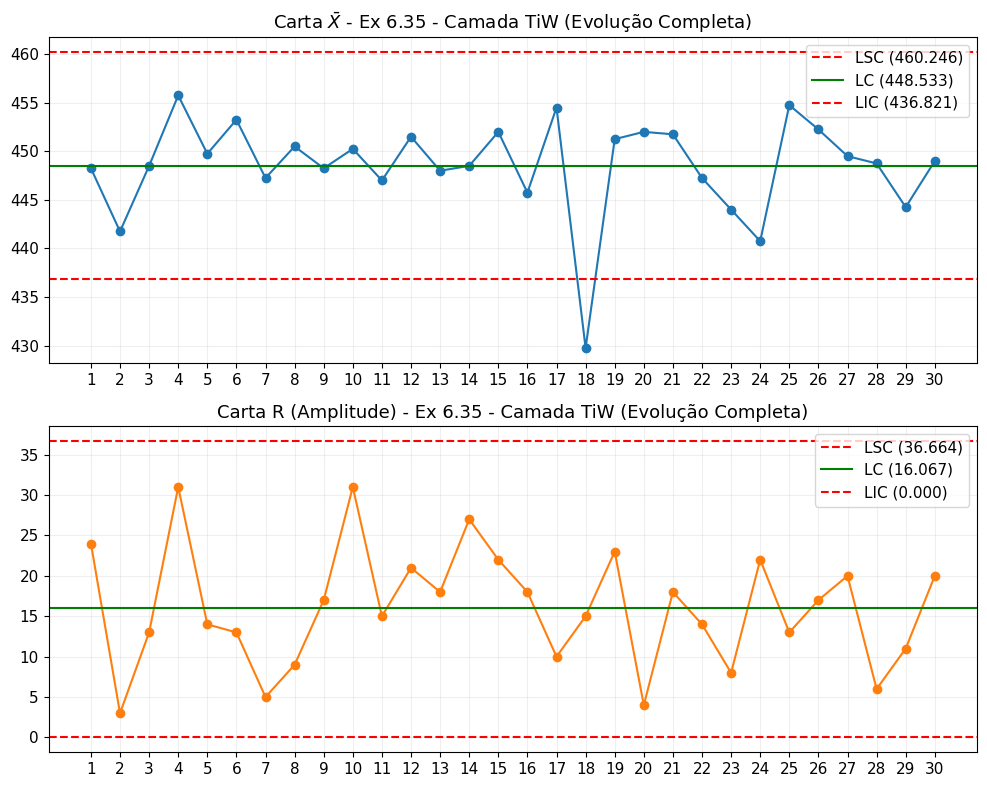

--- RESUMO ESTATÍSTICO: Ex 6.35 - Camada TiW (Evolução Completa) ---
Média do Processo (X̄̄): 448.5333
Variabilidade Média (R̄): 16.0667
Desvio-padrão estimado (σ^): 7.8031


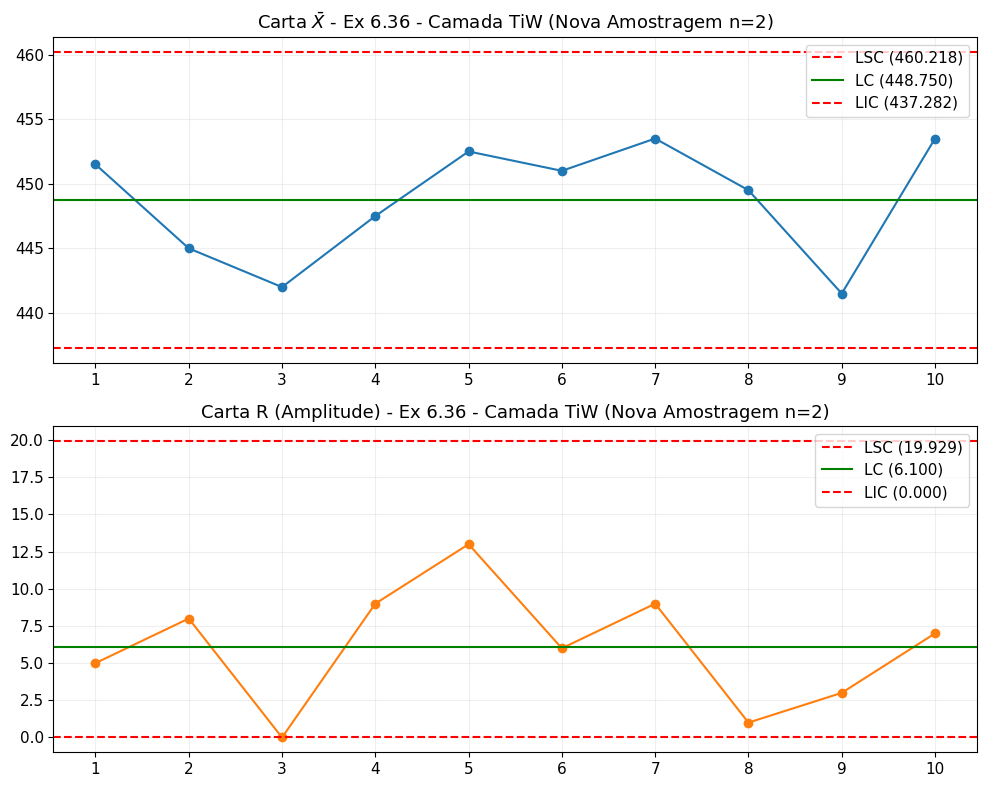

--- RESUMO ESTATÍSTICO: Ex 6.36 - Camada TiW (Nova Amostragem n=2) ---
Média do Processo (X̄̄): 448.7500
Variabilidade Média (R̄): 6.1000
Desvio-padrão estimado (σ^): 5.4078


In [15]:
# EXERCÍCIO 6.35 (Tabela 6E.15) - Novos dados aplicados (Fase II)
dados_novos_6_35 = [
    [454, 449, 443, 461], [449, 441, 444, 455], [442, 442, 442, 450],
    [443, 452, 438, 430], [446, 459, 457, 457], [454, 448, 445, 462],
    [458, 449, 453, 438], [450, 449, 445, 451], [443, 440, 443, 451],
    [457, 450, 452, 437]
]

# Concatenando os dados da Fase I com a Fase II para visualizar a evolução contínua
dados_fase1_e_fase2 = dados_6_34 + dados_novos_6_35
plotar_cartas_brutas(dados_fase1_e_fase2, "Ex 6.35 - Camada TiW (Evolução Completa)", tipo='R')


# EXERCÍCIO 6.36 (Tabela 6E.16) - Mudança de amostragem para n=2
dados_6_36_n2 = [
    [454, 449], [449, 441], [442, 442], [443, 452], [446, 459],
    [454, 448], [458, 449], [450, 449], [443, 440], [457, 450]
]
plotar_cartas_brutas(dados_6_36_n2, "Ex 6.36 - Camada TiW (Nova Amostragem n=2)", tipo='R')

--- FASE I (Apenas dados iniciais) ---


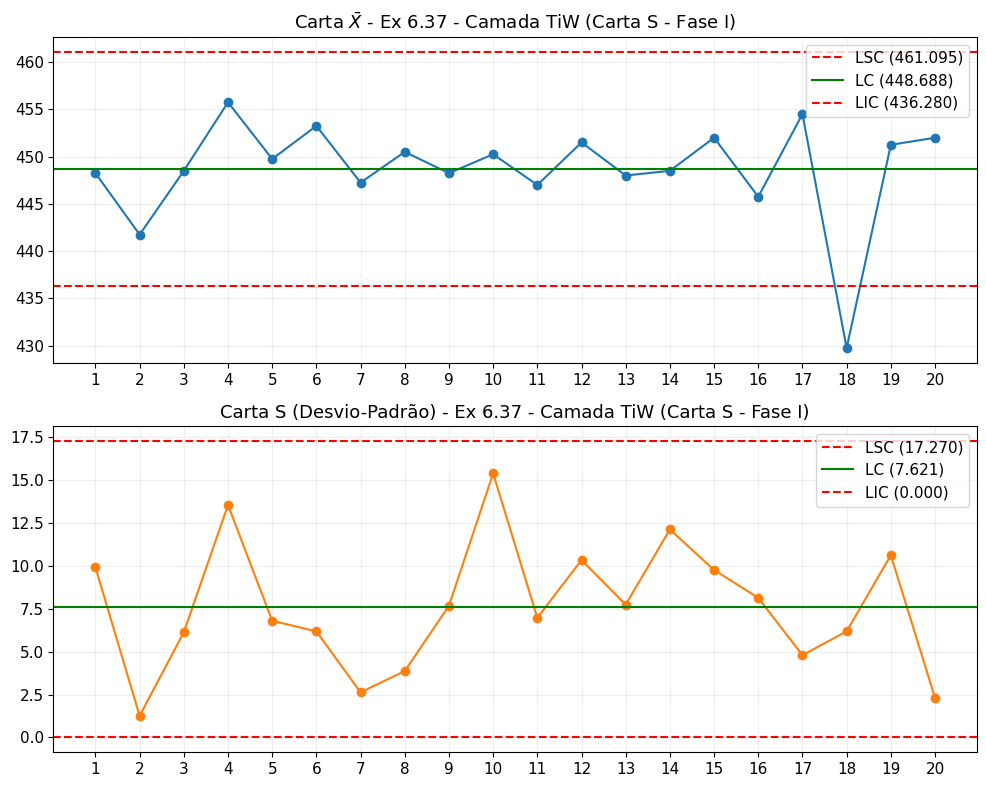

--- RESUMO ESTATÍSTICO: Ex 6.37 - Camada TiW (Carta S - Fase I) ---
Média do Processo (X̄̄): 448.6875
Variabilidade Média (S̄): 7.6212
Desvio-padrão estimado (σ^): 8.2722
--- FASE II (Dados Iniciais + Novos) ---


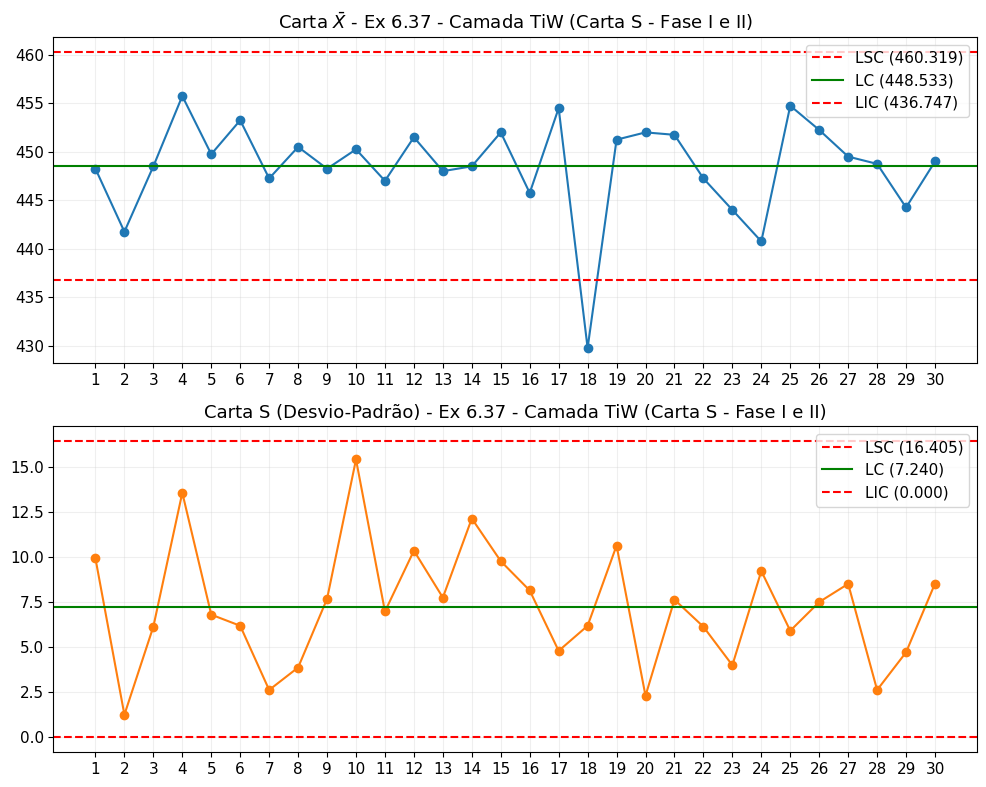

--- RESUMO ESTATÍSTICO: Ex 6.37 - Camada TiW (Carta S - Fase I e II) ---
Média do Processo (X̄̄): 448.5333
Variabilidade Média (S̄): 7.2395
Desvio-padrão estimado (σ^): 7.8580


In [16]:
# EXERCÍCIO 6.37: Refazer 6.34 e 6.35 usando Carta S
# Dados da Fase I (6.34)
dados_6_34 = [
    [459, 449, 435, 450], [443, 440, 442, 442], [457, 444, 449, 444],
    [469, 463, 453, 438], [443, 457, 445, 454], [444, 456, 456, 457],
    [445, 449, 450, 445], [446, 455, 449, 452], [444, 452, 457, 440],
    [432, 463, 463, 443], [445, 452, 453, 438], [456, 457, 436, 457],
    [459, 445, 441, 447], [441, 465, 438, 450], [460, 453, 457, 438],
    [453, 444, 451, 435], [451, 460, 450, 457], [422, 431, 437, 429],
    [444, 446, 448, 467], [450, 450, 454, 454]
]

# Dados da Fase II (6.35)
dados_novos_6_35 = [
    [454, 449, 443, 461], [449, 441, 444, 455], [442, 442, 442, 450],
    [443, 452, 438, 430], [446, 459, 457, 457], [454, 448, 445, 462],
    [458, 449, 453, 438], [450, 449, 445, 451], [443, 440, 443, 451],
    [457, 450, 452, 437]
]

# Avaliação com Carta S
print("--- FASE I (Apenas dados iniciais) ---")
plotar_cartas_brutas(dados_6_34, "Ex 6.37 - Camada TiW (Carta S - Fase I)", tipo='S')

print("--- FASE II (Dados Iniciais + Novos) ---")
plotar_cartas_brutas(dados_6_34 + dados_novos_6_35, "Ex 6.37 - Camada TiW (Carta S - Fase I e II)", tipo='S')

In [17]:
# EXERCÍCIO 6.38 (n=6, m=30, Carta R)
print("=== EXERCÍCIO 6.38 ===")
limites_pelos_somatorios(soma_xbar=6078, soma_var=144, m=30, n=6, tipo='R')

# EXERCÍCIO 6.41 (n=5, m=30, Carta R)
print("=== EXERCÍCIO 6.41 ===")
limites_pelos_somatorios(soma_xbar=2072, soma_var=60, m=30, n=5, tipo='R')

# EXERCÍCIO 6.45 (n=6, m=30, Carta R)
print("=== EXERCÍCIO 6.45 ===")
limites_pelos_somatorios(soma_xbar=12870, soma_var=1350, m=30, n=6, tipo='R')

# EXERCÍCIO 6.46 (n=4, m=30, Carta S)
print("=== EXERCÍCIO 6.46 ===")
limites_pelos_somatorios(soma_xbar=12870, soma_var=410, m=30, n=4, tipo='S')

=== EXERCÍCIO 6.38 ===
Média Global (LC X-barra): 202.6000
Variabilidade (LC R): 4.8000
Limites Carta X-barra: [200.2816 , 204.9184]
Limites Carta R:       [0.0000 , 9.6192]
Desvio-padrão (σ^):    1.8942

=== EXERCÍCIO 6.41 ===
Média Global (LC X-barra): 69.0667
Variabilidade (LC R): 2.0000
Limites Carta X-barra: [67.9127 , 70.2207]
Limites Carta R:       [0.0000 , 4.2280]
Desvio-padrão (σ^):    0.8598

=== EXERCÍCIO 6.45 ===
Média Global (LC X-barra): 429.0000
Variabilidade (LC R): 45.0000
Limites Carta X-barra: [407.2650 , 450.7350]
Limites Carta R:       [0.0000 , 90.1800]
Desvio-padrão (σ^):    17.7585

=== EXERCÍCIO 6.46 ===
Média Global (LC X-barra): 429.0000
Variabilidade (LC S): 13.6667
Limites Carta X-barra: [406.7507 , 451.2493]
Limites Carta S:       [0.0000 , 30.9687]
Desvio-padrão (σ^):    14.8341



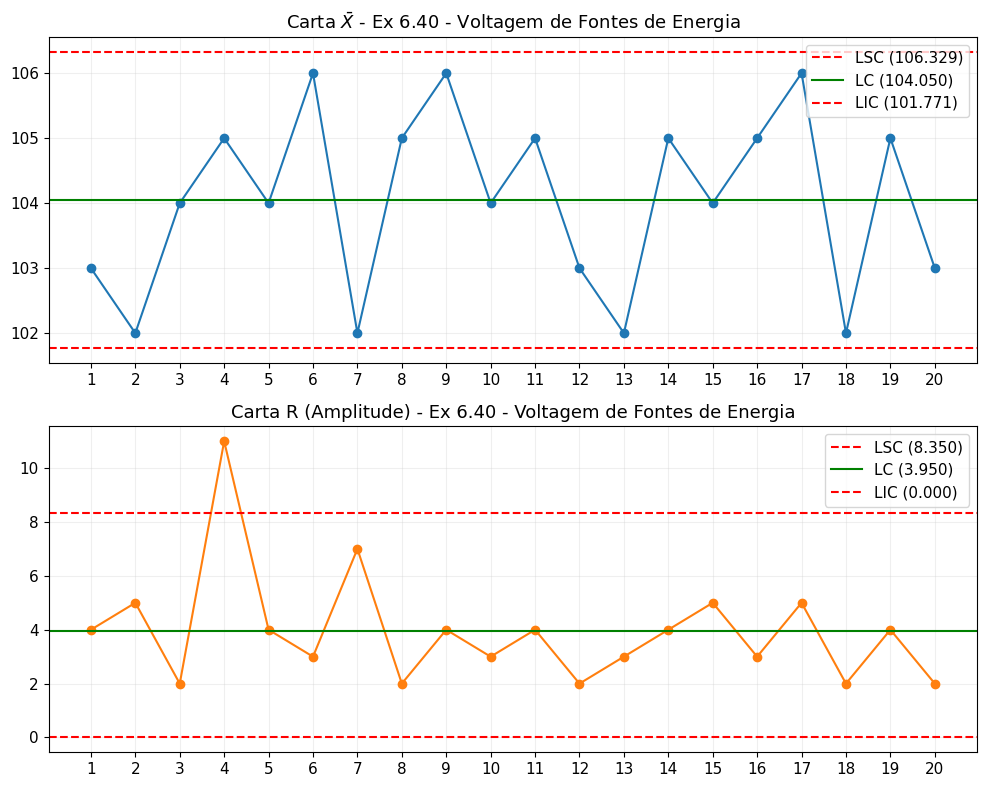

--- RESUMO ESTATÍSTICO: Ex 6.40 - Voltagem de Fontes de Energia ---
Média do Processo (X̄̄): 104.0500
Variabilidade Média (R̄): 3.9500
Desvio-padrão estimado (σ^): 1.6982
Cp (Capacidade do Processo): 0.7851


In [18]:
# EXERCÍCIO 6.40 (Tabela 6E.17) - Voltagem de Saída (n=5)
# Dados já estão na forma (X-barra, R) para cada uma das 20 amostras
xbar_6_40 = [103, 102, 104, 105, 104, 106, 102, 105, 106, 104,
             105, 103, 102, 105, 104, 105, 106, 102, 105, 103]

r_6_40 = [4, 5, 2, 11, 4, 3, 7, 2, 4, 3,
          4, 2, 3, 4, 5, 3, 5, 2, 4, 2]

# A especificação exigida na parte (d) é 103 ± 4 (ou seja, de 99 a 107)
plotar_cartas_resumo(xbar=xbar_6_40, var_amostral=r_6_40, n=5,
                     titulo="Ex 6.40 - Voltagem de Fontes de Energia",
                     especificacao=(99, 107))

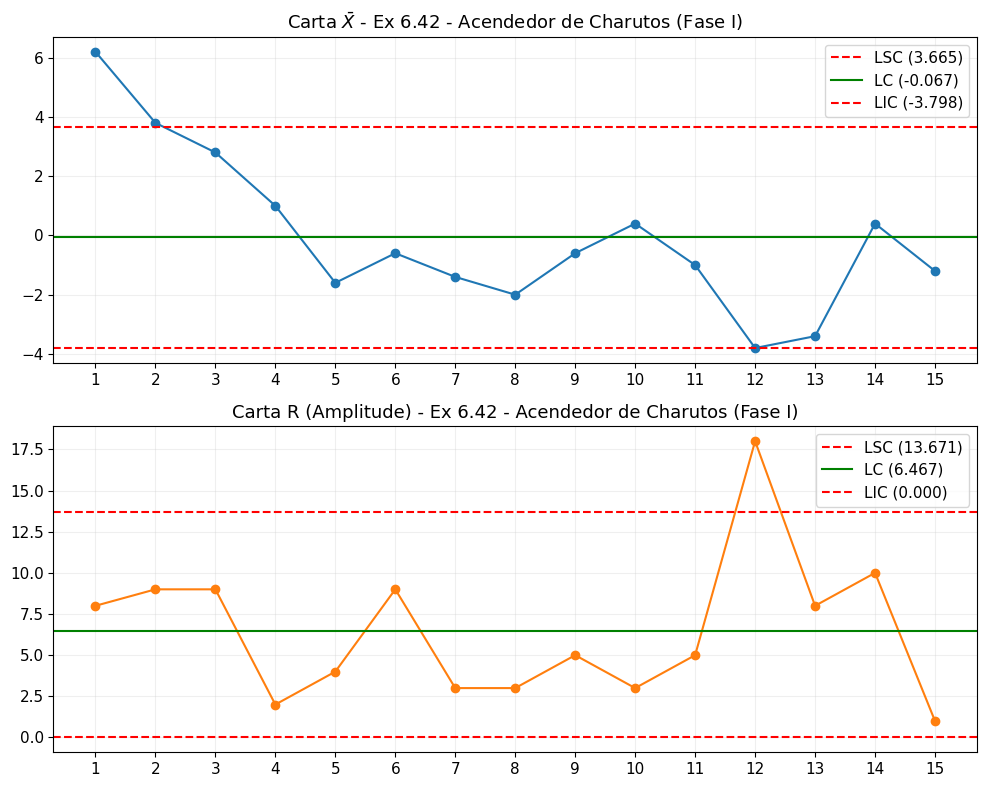

--- RESUMO ESTATÍSTICO: Ex 6.42 - Acendedor de Charutos (Fase I) ---
Média do Processo (X̄̄): -0.0667
Variabilidade Média (R̄): 6.4667
Desvio-padrão estimado (σ^): 2.7802


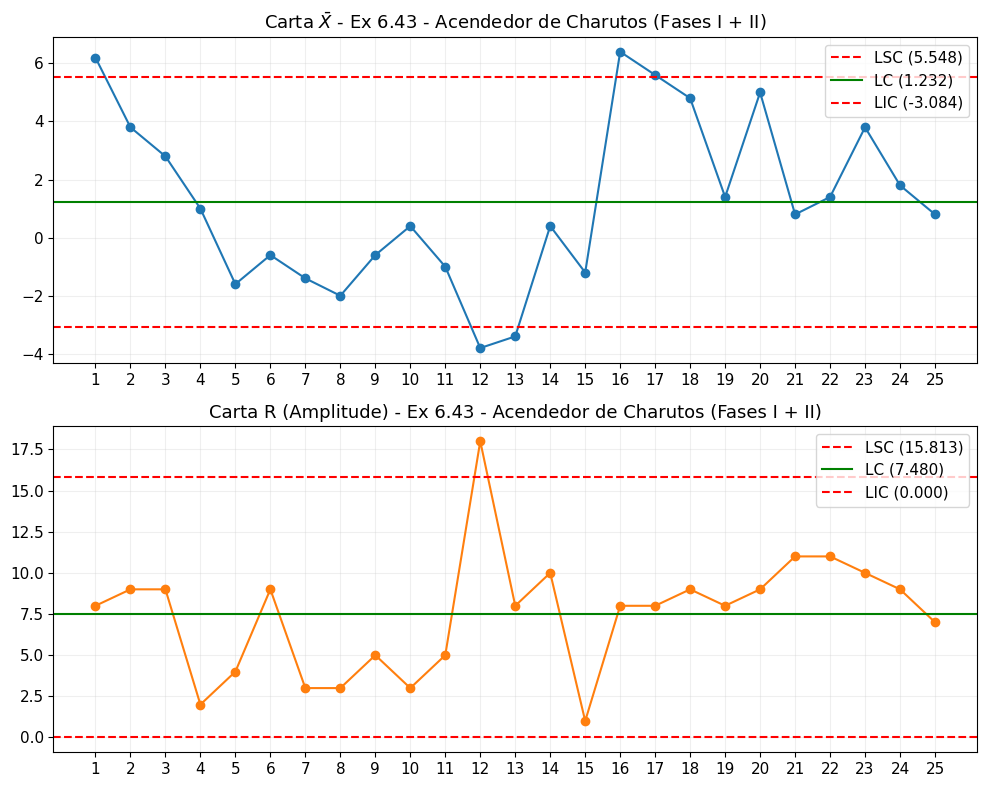

--- RESUMO ESTATÍSTICO: Ex 6.43 - Acendedor de Charutos (Fases I + II) ---
Média do Processo (X̄̄): 1.2320
Variabilidade Média (R̄): 7.4800
Desvio-padrão estimado (σ^): 3.2158


In [19]:
# EXERCÍCIO 6.42 (Tabela 6E.18) - Fase I: 15 Amostras Iniciais (n=5)
# Desvios em relação a 0.3210
dados_6_42 = [
    [ 1,  9,  6,  9,  6], [ 9,  4,  3,  0,  3], [ 0,  9,  0,  3,  2],
    [ 1,  1,  0,  2,  1], [-3,  0, -1,  0, -4], [-7,  2,  0,  0,  2],
    [-3, -1, -1,  0, -2], [ 0, -2, -3, -3, -2], [ 2,  0, -1, -3, -1],
    [ 0,  2, -1, -1,  2], [-3, -2, -1, -1,  2], [-16,  2,  0, -4, -1],
    [-6, -3,  0,  0, -8], [-3, -5,  5,  0,  5], [-1, -1, -1, -2, -1]
]

plotar_cartas_brutas(dados_6_42, "Ex 6.42 - Acendedor de Charutos (Fase I)", tipo='R')


# EXERCÍCIO 6.43 (Tabela 6E.19) - Fase II: Inclusão de 10 Novas Amostras (n=5)
dados_novos_6_43 = [
    [ 2, 10,  9,  6,  5], [ 1,  9,  5,  9,  4], [ 0,  9,  8,  2,  5],
    [-3,  0,  5,  1,  4], [ 2, 10,  9,  3,  1], [-5,  4,  0,  6, -1],
    [ 0,  2, -5,  4,  6], [10,  0,  3,  1,  5], [-1,  2,  5,  6, -3],
    [ 0, -1,  2,  5, -2]
]

# Plotagem da evolução do processo juntando Fase I + Fase II
plotar_cartas_brutas(dados_6_42 + dados_novos_6_43, "Ex 6.43 - Acendedor de Charutos (Fases I + II)", tipo='R')

In [24]:
import scipy.stats as stats

def analisar_capacidade_probabilidade(LC_x, LSC_x, LIC_x, sigma_processo, n, mu_novo=None):
    """
    Função para calcular a probabilidade de detecção de um deslocamento (Poder)
    e o Comprimento Médio da Sequência (CMS/ARL).
    """
    # Desvio padrão da média amostral
    sigma_xbar = sigma_processo / np.sqrt(n)

    if mu_novo:
        # Erro Tipo II (Beta) - Probabilidade do ponto cair dentro dos limites MESMO com o processo deslocado
        Z_sup = (LSC_x - mu_novo) / sigma_xbar
        Z_inf = (LIC_x - mu_novo) / sigma_xbar
        beta = stats.norm.cdf(Z_sup) - stats.norm.cdf(Z_inf)

        # Poder de detecção (Probabilidade de cair fora dos limites na primeira amostra)
        poder = 1 - beta

        # CMS (ARL1) - Número médio de amostras até o alarme
        cms = 1 / poder if poder > 0 else np.inf

        print(f"Para um deslocamento da média para {mu_novo}:")
        print(f"Probabilidade de detecção na 1ª amostra (1 - β): {poder:.4f} ({poder*100:.2f}%)")
        print(f"Probabilidade de NÃO detectar na 1ª amostra (β): {beta:.4f} ({beta*100:.2f}%)")
        print(f"CMS (Comprimento Médio da Sequência até detectar): {cms:.2f} amostras\n")
    else:
        # Erro Tipo I (Alpha) - Falso alarme
        Z_sup = (LSC_x - LC_x) / sigma_xbar
        Z_inf = (LIC_x - LC_x) / sigma_xbar
        alpha = 1 - (stats.norm.cdf(Z_sup) - stats.norm.cdf(Z_inf))
        cms0 = 1 / alpha

        print(f"Sem deslocamento (Processo sob controle):")
        print(f"Probabilidade de falso alarme (Erro Tipo I - α): {alpha:.6f}")
        print(f"CMS0 (Amostras até um falso alarme): {cms0:.2f}\n")

# RESOLUÇÕES DIRETAS DE PROBLEMAS TEÓRICOS CHAVE:
print("=== EXERCÍCIO 6.48 & 6.49 ===")
# LSC=104, LC=100, LIC=96, n=5, sigma=8. Deslocamento para mu=98.
analisar_capacidade_probabilidade(LC_x=100, LSC_x=104, LIC_x=96, sigma_processo=8, n=5, mu_novo=98)

print("=== EXERCÍCIO 6.55 & 6.56 ===")
# LSC=815, LC=800, LIC=785, n=4. Deslocamento para 790.
# O desvio padrão deve ser estimado de LSC = LC + 3*(sigma/sqrt(n)) -> 815 = 800 + 3*(sigma/2) -> sigma = 10
analisar_capacidade_probabilidade(LC_x=800, LSC_x=815, LIC_x=785, sigma_processo=10, n=4, mu_novo=790)

print("=== EXERCÍCIO 6.53 (n=7, m=30) ===")
# Usando a função da célula anterior
limites_pelos_somatorios(soma_xbar=2700, soma_var=120, m=30, n=7, tipo='R')

=== EXERCÍCIO 6.48 & 6.49 ===
Para um deslocamento da média para 98:
Probabilidade de detecção na 1ª amostra (1 - β): 0.3348 (33.48%)
Probabilidade de NÃO detectar na 1ª amostra (β): 0.6652 (66.52%)
CMS (Comprimento Médio da Sequência até detectar): 2.99 amostras

=== EXERCÍCIO 6.55 & 6.56 ===
Para um deslocamento da média para 790:
Probabilidade de detecção na 1ª amostra (1 - β): 0.1587 (15.87%)
Probabilidade de NÃO detectar na 1ª amostra (β): 0.8413 (84.13%)
CMS (Comprimento Médio da Sequência até detectar): 6.30 amostras

=== EXERCÍCIO 6.53 (n=7, m=30) ===
Média Global (LC X-barra): 90.0000
Variabilidade (LC R): 4.0000
Limites Carta X-barra: [88.3240 , 91.6760]
Limites Carta R:       [0.3040 , 7.6960]
Desvio-padrão (σ^):    1.4793



In [25]:
def plotar_cartas_individuais(dados, titulo, especificacao=None):
    """Gera cartas I-MR (Individual - Moving Range) para n=1"""
    m = len(dados)
    x = np.array(dados)

    # Cálculo da Amplitude Móvel (Moving Range - abrangência n=2)
    mr = np.abs(np.diff(x))
    mr = np.insert(mr, 0, np.nan) # O primeiro item não tem MR

    x_bar = np.mean(x)
    mr_bar = np.nanmean(mr)

    # Constantes para Carta MR com abrangência n=2
    d2 = CONSTANTES[2]['d2']
    D3 = CONSTANTES[2]['D3']
    D4 = CONSTANTES[2]['D4']

    # Limites da Carta Individual (I ou X)
    LSC_x = x_bar + 3 * (mr_bar / d2)
    LIC_x = x_bar - 3 * (mr_bar / d2)

    # Limites da Carta Amplitude Móvel (MR)
    LSC_mr = D4 * mr_bar
    LIC_mr = D3 * mr_bar

    sigma_est = mr_bar / d2

    # Plotagem
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # Carta Individual
    ax1.plot(range(1, m+1), x, marker='o', color='#1f77b4')
    ax1.axhline(LSC_x, color='red', linestyle='--', label=f'LSC ({LSC_x:.3f})')
    ax1.axhline(x_bar, color='green', label=f'LC ({x_bar:.3f})')
    ax1.axhline(LIC_x, color='red', linestyle='--', label=f'LIC ({LIC_x:.3f})')
    ax1.set_title(f'Carta de Observações Individuais (X) - {titulo}')
    ax1.set_xticks(range(1, m+1))
    ax1.legend(loc='upper right')

    # Carta Moving Range (MR)
    ax2.plot(range(1, m+1), mr, marker='o', color='#ff7f0e')
    ax2.axhline(LSC_mr, color='red', linestyle='--', label=f'LSC ({LSC_mr:.3f})')
    ax2.axhline(mr_bar, color='green', label=f'LC ({mr_bar:.3f})')
    ax2.axhline(LIC_mr, color='red', linestyle='--', label=f'LIC ({LIC_mr:.3f})')
    ax2.set_title(f'Carta de Amplitude Móvel (MR) - {titulo}')
    ax2.set_xticks(range(1, m+1))
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    print(f"--- RESUMO ESTATÍSTICO: {titulo} ---")
    print(f"Média Individual (X̄): {x_bar:.4f}")
    print(f"Amplitude Móvel Média (MR̄): {mr_bar:.4f}")
    print(f"Desvio-padrão estimado (σ^): {sigma_est:.4f}")
    if especificacao:
        Cp = (especificacao[1] - especificacao[0]) / (6 * sigma_est)
        print(f"Cp (Capacidade do Processo): {Cp:.4f}")

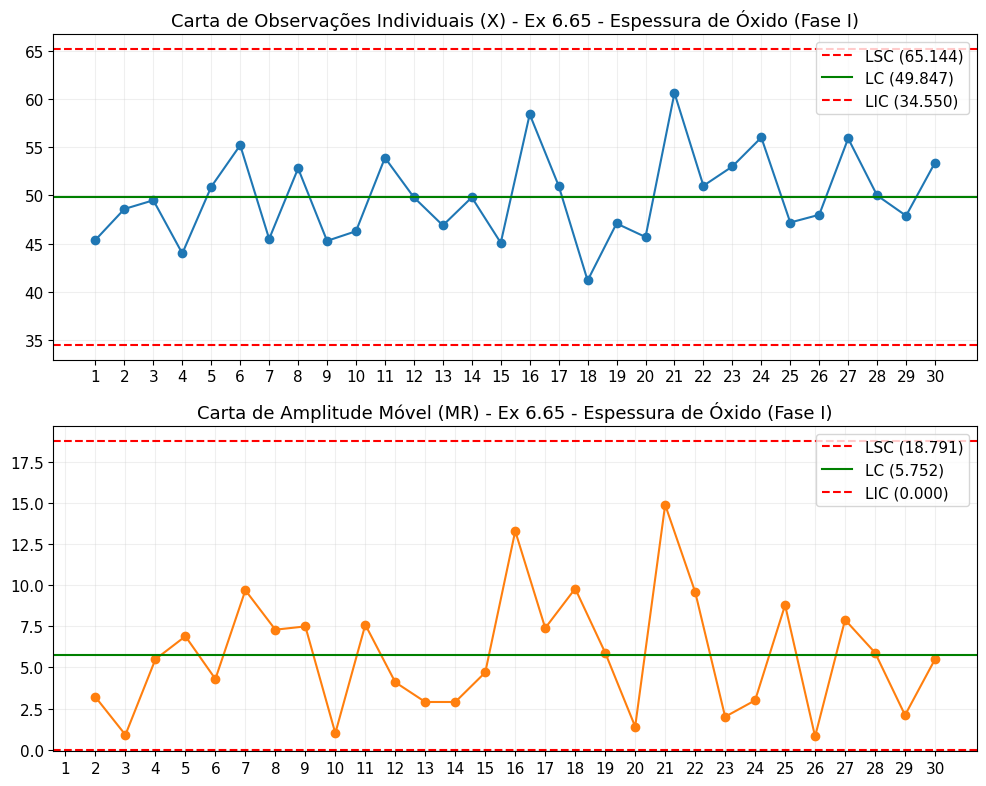

--- RESUMO ESTATÍSTICO: Ex 6.65 - Espessura de Óxido (Fase I) ---
Média Individual (X̄): 49.8467
Amplitude Móvel Média (MR̄): 5.7517
Desvio-padrão estimado (σ^): 5.0990


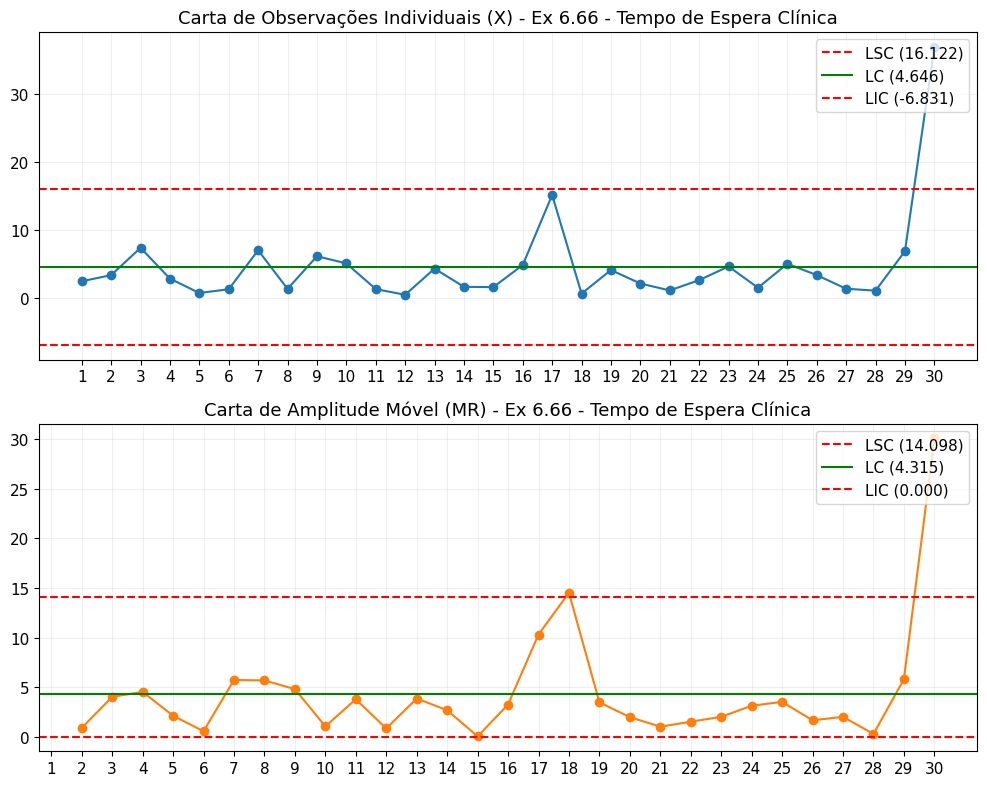

--- RESUMO ESTATÍSTICO: Ex 6.66 - Tempo de Espera Clínica ---
Média Individual (X̄): 4.6457
Amplitude Móvel Média (MR̄): 4.3152
Desvio-padrão estimado (σ^): 3.8255


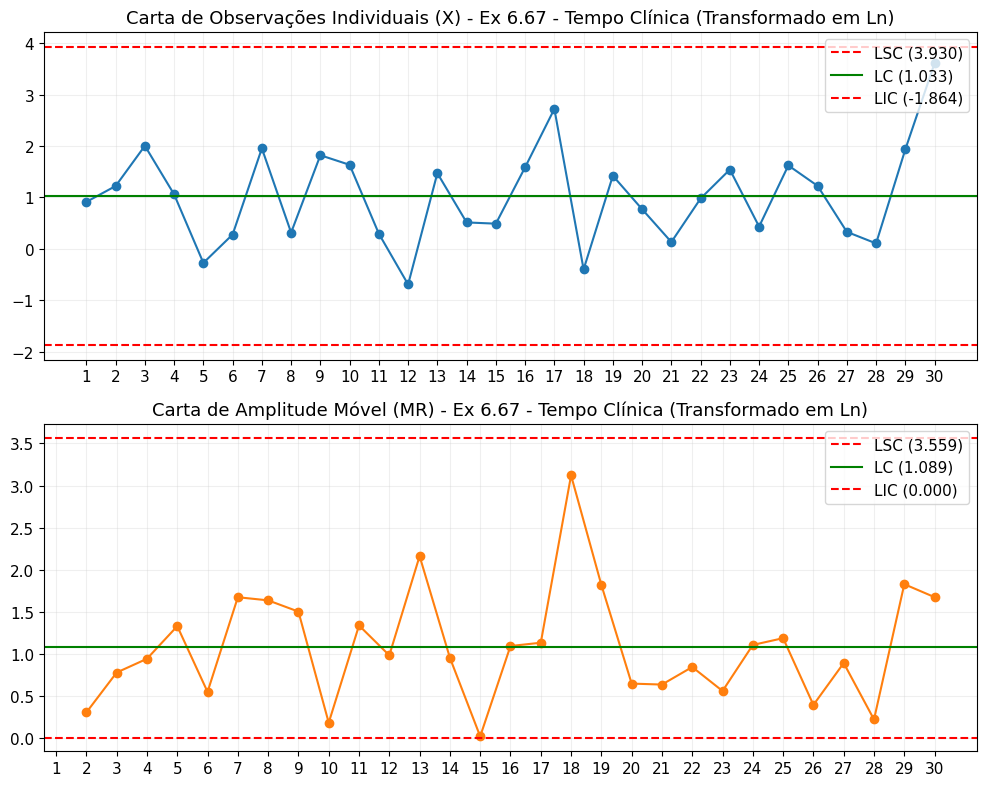

--- RESUMO ESTATÍSTICO: Ex 6.67 - Tempo Clínica (Transformado em Ln) ---
Média Individual (X̄): 1.0330
Amplitude Móvel Média (MR̄): 1.0894
Desvio-padrão estimado (σ^): 0.9658


In [23]:
# EXERCÍCIO 6.65 (Tabela 6E.23) - Espessura de Óxido (Placas) - Apenas Fase 1
dados_6_65 = [
    45.4, 48.6, 49.5, 44.0, 50.9, 55.2, 45.5, 52.8, 45.3, 46.3,
    53.9, 49.8, 46.9, 49.8, 45.1, 58.4, 51.0, 41.2, 47.1, 45.7,
    60.6, 51.0, 53.0, 56.0, 47.2, 48.0, 55.9, 50.0, 47.9, 53.4
]
plotar_cartas_individuais(dados_6_65, "Ex 6.65 - Espessura de Óxido (Fase I)")

# EXERCÍCIO 6.66 (Tabela 6E.24) - Tempo de Espera em Clínica (Drogaria)
# O livro sugere que estes dados têm longa cauda à direita (não-normais)
dados_6_66 = [
    2.49, 3.39, 7.41, 2.88, 0.76, 1.32, 7.05, 1.37, 6.17, 5.12,
    1.34, 0.50, 4.35, 1.67, 1.63, 4.88, 15.19, 0.67, 4.14, 2.16,
    1.14, 2.66, 4.67, 1.54, 5.06, 3.40, 1.39, 1.11, 6.92, 36.99
]
plotar_cartas_individuais(dados_6_66, "Ex 6.66 - Tempo de Espera Clínica")

# No Exercício 6.67 (continuação do 6.66), o livro pede para aplicar Transformação Logarítmica Natural (ln)
# pois dados de "Tempo de Espera" costumam seguir distribuição Lognormal ou Exponencial.
dados_6_67_log = np.log(dados_6_66)
plotar_cartas_individuais(dados_6_67_log, "Ex 6.67 - Tempo Clínica (Transformado em Ln)")

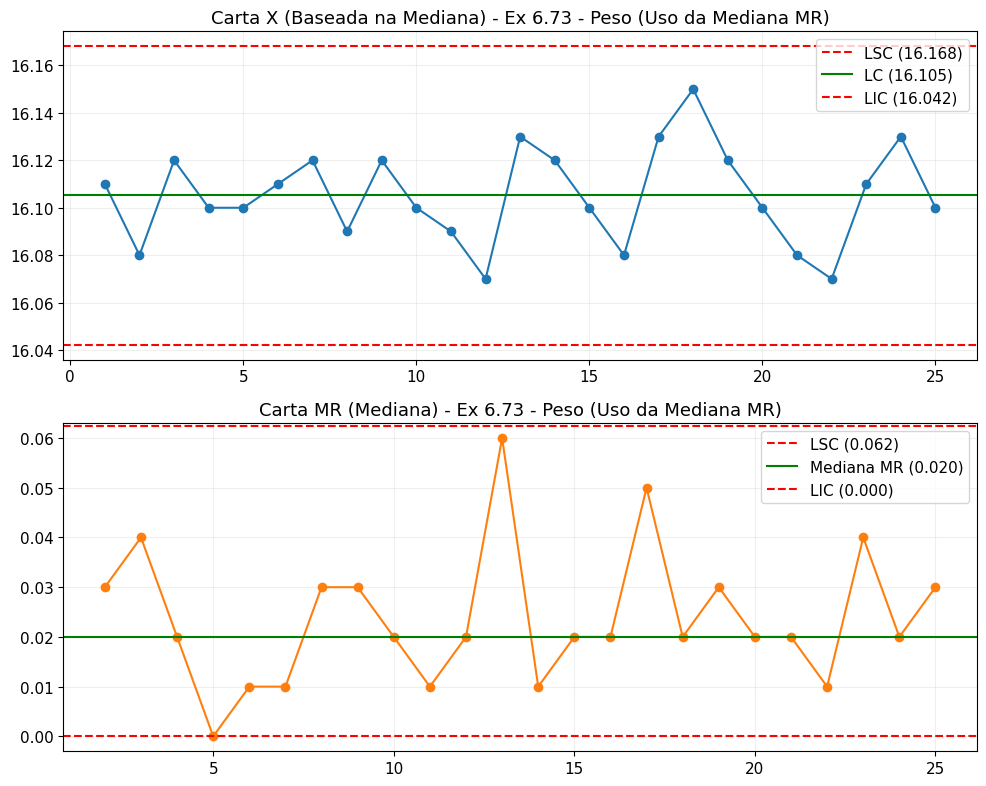

--- RESUMO ESTATÍSTICO: Ex 6.73 - Peso (Uso da Mediana MR) ---
Desvio-padrão estimado pela MEDIANA (σ^): 0.0210


In [28]:
def plotar_cartas_individuais_mediana(dados, titulo):
    """Gera cartas I-MR utilizando a MEDIANA das amplitudes móveis (reduz efeito de outliers)"""
    m = len(dados)
    x = np.array(dados)

    mr = np.abs(np.diff(x))
    mr = np.insert(mr, 0, np.nan)

    x_bar = np.mean(x)
    mr_mediana = np.nanmedian(mr)

    # Constante d4 para a mediana com n=2 é aprox 0.954 (substitui o d2 = 1.128 da média)
    d4_mediana = 0.954
    D3_mediana = 0
    D4_mediana = 3.117 # D4 aproximado para limite superior com mediana

    LSC_x = x_bar + 3 * (mr_mediana / d4_mediana)
    LIC_x = x_bar - 3 * (mr_mediana / d4_mediana)

    LSC_mr = D4_mediana * mr_mediana
    LIC_mr = D3_mediana * mr_mediana

    sigma_est = mr_mediana / d4_mediana

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(range(1, m+1), x, marker='o', color='#1f77b4')
    ax1.axhline(LSC_x, color='red', linestyle='--', label=f'LSC ({LSC_x:.3f})')
    ax1.axhline(x_bar, color='green', label=f'LC ({x_bar:.3f})')
    ax1.axhline(LIC_x, color='red', linestyle='--', label=f'LIC ({LIC_x:.3f})')
    ax1.set_title(f'Carta X (Baseada na Mediana) - {titulo}')
    ax1.legend(loc='upper right')

    ax2.plot(range(1, m+1), mr, marker='o', color='#ff7f0e')
    ax2.axhline(LSC_mr, color='red', linestyle='--', label=f'LSC ({LSC_mr:.3f})')
    ax2.axhline(mr_mediana, color='green', label=f'Mediana MR ({mr_mediana:.3f})')
    ax2.axhline(LIC_mr, color='red', linestyle='--', label=f'LIC ({LIC_mr:.3f})')
    ax2.set_title(f'Carta MR (Mediana) - {titulo}')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    print(f"--- RESUMO ESTATÍSTICO: {titulo} ---")
    print(f"Desvio-padrão estimado pela MEDIANA (σ^): {sigma_est:.4f}")

# Reaplicando no Ex 6.61 (Agora como Exercício 6.73)
dados_6_61 = [
    16.11, 16.08, 16.12, 16.10, 16.10, 16.11, 16.12, 16.09, 16.12, 16.10,
    16.09, 16.07, 16.13, 16.12, 16.10, 16.08, 16.13, 16.15, 16.12, 16.10,
    16.08, 16.07, 16.11, 16.13, 16.10
]
plotar_cartas_individuais_mediana(dados_6_61, "Ex 6.73 - Peso (Uso da Mediana MR)")

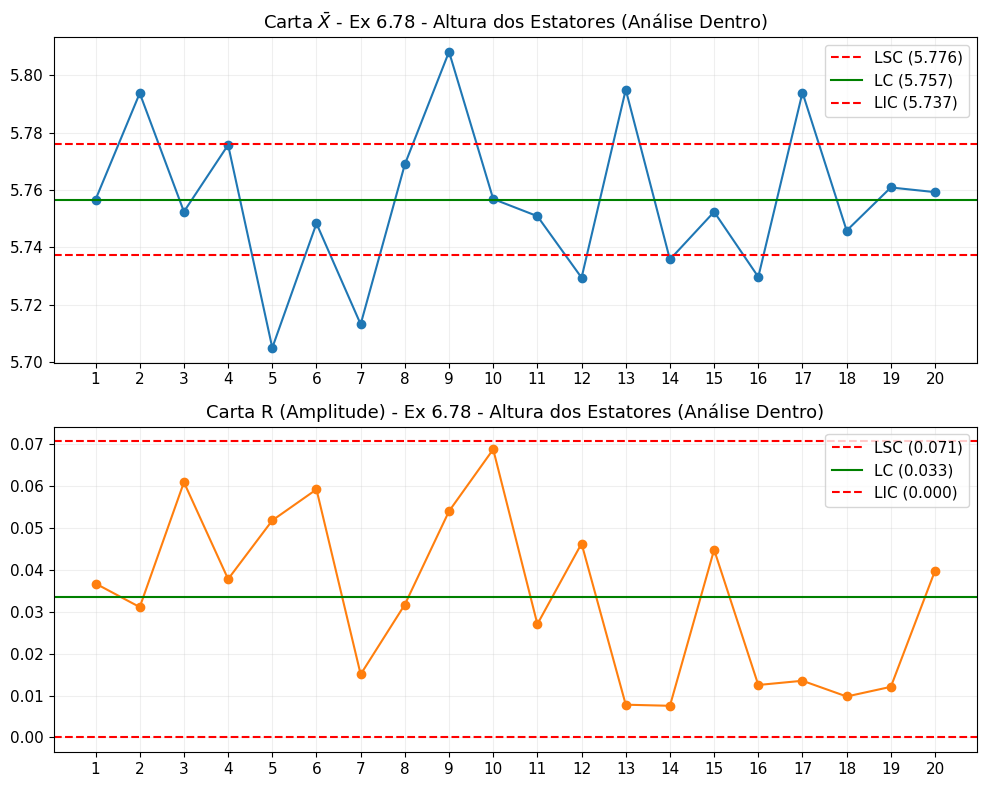

--- RESUMO ESTATÍSTICO: Ex 6.78 - Altura dos Estatores (Análise Dentro) ---
Média do Processo (X̄̄): 5.7566
Variabilidade Média (R̄): 0.0335
Desvio-padrão estimado (σ^): 0.0144


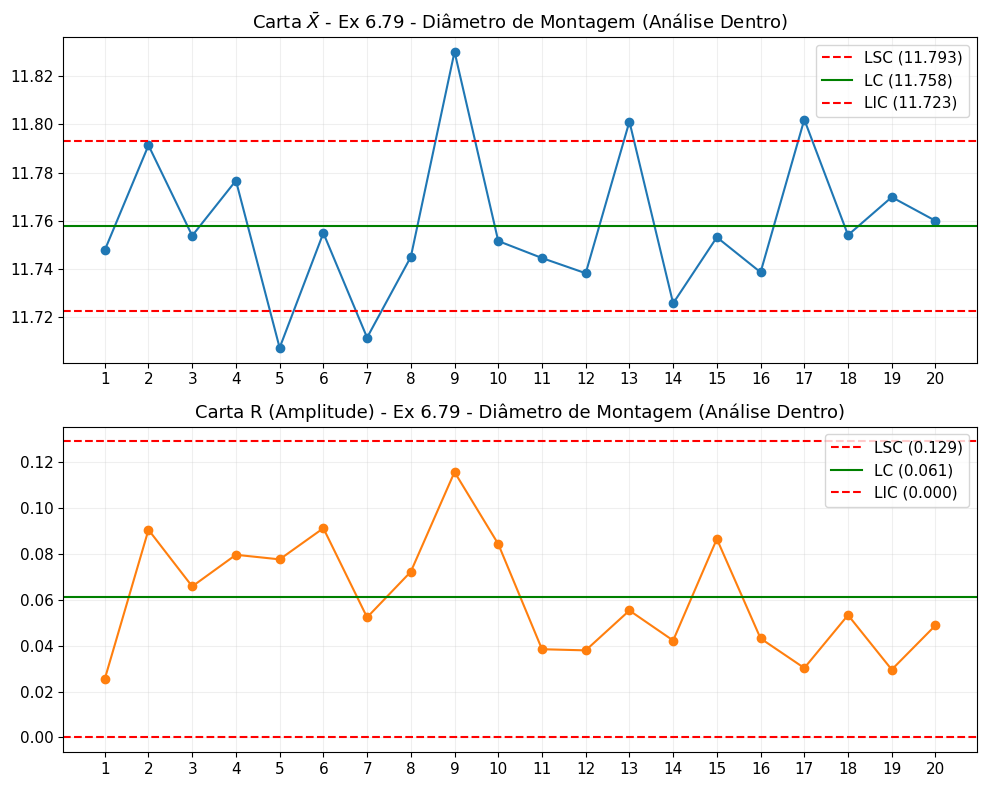

--- RESUMO ESTATÍSTICO: Ex 6.79 - Diâmetro de Montagem (Análise Dentro) ---
Média do Processo (X̄̄): 11.7579
Variabilidade Média (R̄): 0.0611
Desvio-padrão estimado (σ^): 0.0263


In [29]:
# EXERCÍCIO 6.78 (Tabela 6E.32) - Altura dos Estatores
# Avaliando as 5 medições em cada uma das 20 montagens (n=5)
dados_6_78 = [
    [5.77799, 5.74907, 5.76672, 5.74836, 5.74122],
    [5.79090, 5.78043, 5.79163, 5.79393, 5.81158],
    [5.77314, 5.71216, 5.74810, 5.77292, 5.75591],
    [5.77030, 5.75903, 5.77157, 5.79687, 5.78063],
    [5.72047, 5.68587, 5.73302, 5.70472, 5.68116],
    [5.77265, 5.76426, 5.74373, 5.71338, 5.74765],
    [5.70581, 5.70835, 5.71866, 5.71252, 5.72089],
    [5.76466, 5.78766, 5.76115, 5.77523, 5.75590],
    [5.79397, 5.83308, 5.77902, 5.81122, 5.82335],
    [5.78671, 5.76411, 5.75941, 5.75619, 5.71787],
    [5.75352, 5.74144, 5.74109, 5.76817, 5.75019],
    [5.72787, 5.70716, 5.75349, 5.72389, 5.73488],
    [5.79707, 5.79231, 5.79022, 5.79694, 5.79805],
    [5.73765, 5.73615, 5.73249, 5.74006, 5.73265],
    [5.72477, 5.76565, 5.76963, 5.74993, 5.75196],
    [5.73199, 5.72926, 5.72963, 5.72259, 5.73513],
    [5.79166, 5.79516, 5.79903, 5.78548, 5.79826],
    [5.74973, 5.74863, 5.73994, 5.74405, 5.74682],
    [5.76449, 5.75632, 5.76197, 5.76684, 5.75474],
    [5.75168, 5.75579, 5.73979, 5.77963, 5.76933]
]
plotar_cartas_brutas(dados_6_78, "Ex 6.78 - Altura dos Estatores (Análise Dentro)", tipo='R')


# EXERCÍCIO 6.79 (Tabela 6E.33) - Diâmetro de Montagem (n=5)
dados_6_79 = [
    [11.7629, 11.7403, 11.7511, 11.7474, 11.7374],
    [11.8122, 11.7506, 11.7787, 11.7736, 11.8412],
    [11.7742, 11.7114, 11.7530, 11.7532, 11.7773],
    [11.7833, 11.7311, 11.7777, 11.8108, 11.7804],
    [11.7134, 11.6870, 11.7305, 11.7419, 11.6642],
    [11.7925, 11.7611, 11.7588, 11.7012, 11.7611],
    [11.6916, 11.7205, 11.6958, 11.7440, 11.7062],
    [11.7109, 11.7832, 11.7496, 11.7496, 11.7318],
    [11.7984, 11.8887, 11.7729, 11.8485, 11.8416],
    [11.7914, 11.7613, 11.7356, 11.7628, 11.7070],
    [11.7260, 11.7329, 11.7424, 11.7645, 11.7571],
    [11.7202, 11.7537, 11.7328, 11.7582, 11.7265],
    [11.8356, 11.7971, 11.8023, 11.7802, 11.7903],
    [11.7069, 11.7112, 11.7492, 11.7329, 11.7289],
    [11.7116, 11.7978, 11.7982, 11.7429, 11.7154],
    [11.7165, 11.7284, 11.7571, 11.7597, 11.7317],
    [11.8022, 11.8127, 11.7864, 11.7917, 11.8167],
    [11.7775, 11.7372, 11.7241, 11.7773, 11.7543],
    [11.7753, 11.7870, 11.7574, 11.7620, 11.7673],
    [11.7572, 11.7626, 11.7523, 11.7395, 11.7884]
]
plotar_cartas_brutas(dados_6_79, "Ex 6.79 - Diâmetro de Montagem (Análise Dentro)", tipo='R')